# Presentation Visuals — Storytelling

Generates publication-quality figures for each key slide.

| Figure | Slide | File |
|---|---|---|
| Hierarchy + Demand Distribution | The Problem | `plots/slide_hierarchy_kde.png` |
| Zero-demand cascade (S&OP) | The Problem | `plots/slide_zero_cascade.png` |
| Time-series spaghetti | The Problem | `plots/slide_spaghetti.png` |
| Demand heatmap (series × time) | The Problem | `plots/slide_heatmap.png` |
| Regional longitudinal trends | EDA | `plots/slide_regional_trends.png` |
| Train/test cutoff | EDA | `plots/slide_eda_cutoff.png` |
| MSTL decomposition (periods 4 + 13) | EDA | `plots/slide_eda_decomposition.png` |
| Avg ACF by demand type (lag justification) | EDA | `plots/slide_eda_lag_selection.png` |
| ACF + PACF — national aggregate | EDA | `plots/slide_eda_acf.png` |
| Outlier detection (z-score) | EDA | `plots/slide_eda_outliers.png` |
| Syntetos-Boylan matrix | Demand Segmentation | `plots/slide_segmentation.png` |
| Modeling strategy diagram | Modeling Strategy | `plots/slide_modeling_strategy.png` |
| Feature groups + SHAP | Feature Engineering | `plots/slide_feature_engineering.png` |
| WAPE results | Results | `plots/slide_results.png` |

In [83]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import os

import sys
sys.path.insert(0, '../../src')
from config import LoadConfig

warnings.filterwarnings('ignore')
os.makedirs('../../plots', exist_ok=True)

cfg = LoadConfig()

# ── Corporate palette ────────────────────────────────────────────────────────
BLUE_GRADIENT = ['#1B3A6B', '#2E6DB4', '#4A90C4', '#6EB5D8']

# Monochromatic blue — dark → light (5 steps for 5 regions)
REGION_COLORS = ['#003D60', '#005586', '#119FDA', '#4DB4E0', '#7FA8C2']

DEMAND_COLORS = {
    'smooth':       '#2E6DB4',
    'erratic':      '#F28E2B',
    'intermittent': '#59A14F',
    'lumpy':        '#E15759',
}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linestyle':    '--',
})
print('Setup ok')

Setup ok


---
## Figure 1 — Data Hierarchy & Demand Distribution
**Slide 2 — The Problem**

Two-panel figure:
- **Left**: hierarchy tree showing data granularity levels with series counts
- **Right**: log-scale KDE of weekly demand by region — surfaces the zero-inflation and long tail

In [84]:
# ── Load data ─────────────────────────────────────────────────────────────────
df_features = cfg.load_forecast('features', 'static')
df_base     = cfg.load_forecast('datasets', 'base').rename(columns={'time_series_id': 'unique_id',
                                                                'week': 'ds',
                                                                'units_sold': 'y'})
df_tags     = cfg.load_forecast('tags', 'series').rename(columns={'time_series_id': 'unique_id'})

# Merge region into base sales
region_map   = df_features[['unique_id', 'region_id']].drop_duplicates()
df_sales     = df_base.merge(region_map, on=['unique_id', 'region_id'], how='left')

# Hierarchy counts
n_series    = df_features['unique_id'].nunique()
n_regions   = df_features['region_id'].nunique()
n_suppliers = df_features['supplier_id'].nunique()

print(f'Series    : {n_series:,}')
print(f'Regions   : {n_regions}')
print(f'Suppliers : {n_suppliers}')
print(f'Weeks     : {df_base["ds"].nunique()}')
print(f'Zero rate : {(df_base["y"] == 0).mean():.1%}')

Series    : 2,232
Regions   : 5
Suppliers : 26
Weeks     : 52
Zero rate : 36.9%


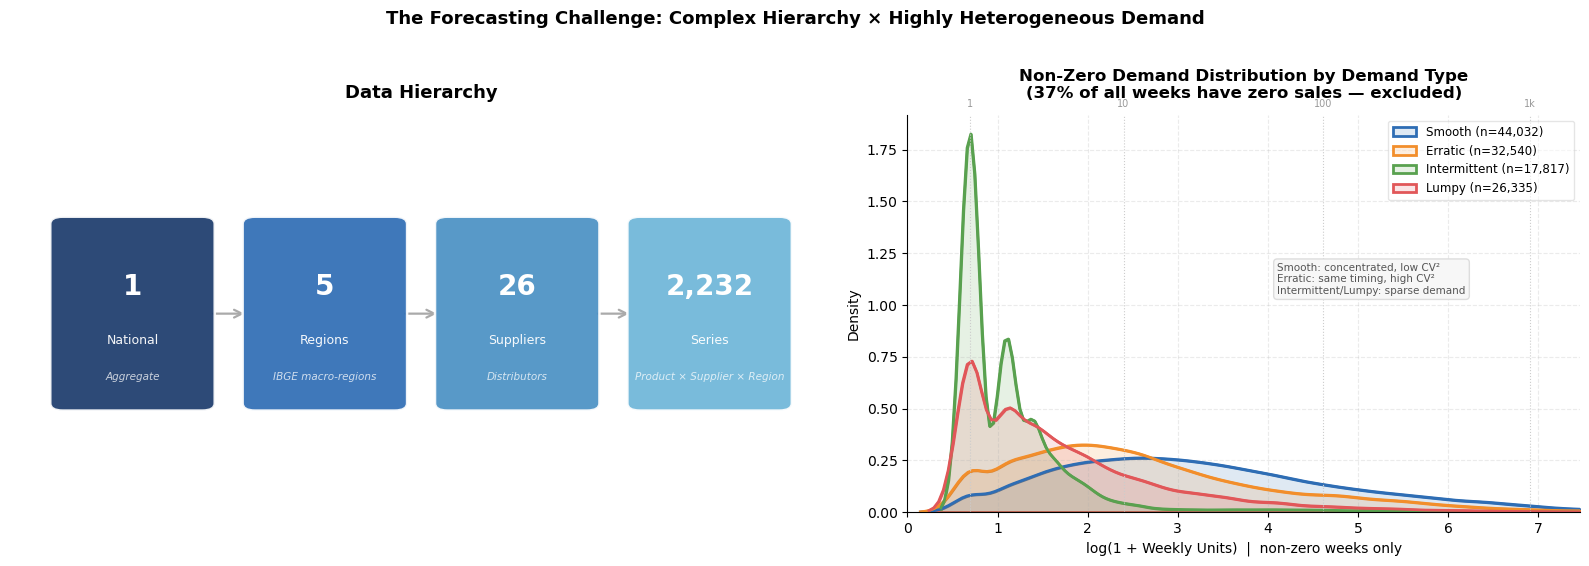

Saved: plots/slide_hierarchy_kde.png


In [85]:
def _draw_hierarchy(ax, levels, colors):
    """Draw a horizontal hierarchy diagram with rounded boxes and arrows."""
    n      = len(levels)
    box_w  = 0.17
    box_h  = 0.38
    gap    = (1.0 - n * box_w) / (n + 1)
    y_c    = 0.50

    for i, (title, count, sublabel) in enumerate(levels):
        x = gap + i * (box_w + gap)
        y = y_c - box_h / 2

        box = FancyBboxPatch(
            (x, y), box_w, box_h,
            boxstyle='round,pad=0.015',
            facecolor=colors[i], edgecolor='white',
            linewidth=1.8, zorder=2, alpha=0.92,
        )
        ax.add_patch(box)

        ax.text(x + box_w / 2, y + box_h * 0.65, f'{count:,}',
                ha='center', va='center',
                fontsize=20, fontweight='bold', color='white', zorder=3)
        ax.text(x + box_w / 2, y + box_h * 0.35, title,
                ha='center', va='center',
                fontsize=9, color='white', alpha=0.95, zorder=3)
        if sublabel:
            ax.text(x + box_w / 2, y + box_h * 0.15, sublabel,
                    ha='center', va='center',
                    fontsize=7.5, color='white', alpha=0.75, zorder=3,
                    style='italic')

        if i < n - 1:
            ax.annotate(
                '',
                xy=(x + box_w + gap * 0.85, y_c),
                xytext=(x + box_w + gap * 0.15, y_c),
                arrowprops=dict(arrowstyle='->', color='#aaaaaa',
                               lw=1.6, mutation_scale=14),
                zorder=1,
            )

    ax.set_xlim(0, 1)
    ax.set_ylim(0.08, 0.92)
    ax.axis('off')


# ── Hierarchy levels ──────────────────────────────────────────────────────────
levels = [
    ('National',  1,          'Aggregate'),
    ('Regions',   n_regions,  'IBGE macro-regions'),
    ('Suppliers', n_suppliers,'Distributors'),
    ('Series',    n_series,   'Product × Supplier × Region'),
]

# ── Merge demand type into base sales ─────────────────────────────────────────
demand_map = df_tags[['unique_id', 'demand_type']].drop_duplicates()
df_sales   = df_base.merge(demand_map, on='unique_id', how='left')
zero_rate  = (df_sales['y'] == 0).mean()

# Non-zero only — reveals true dispersion of active demand
df_nonzero = df_sales[df_sales['y'] > 0]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 5.5),
    gridspec_kw={'width_ratios': [1.1, 0.9]},
)
fig.patch.set_facecolor('white')

# ── Panel A: Hierarchy ────────────────────────────────────────────────────────
_draw_hierarchy(axes[0], levels, BLUE_GRADIENT)
axes[0].set_title('Data Hierarchy', fontsize=13, fontweight='bold', pad=12)

# ── Panel B: KDE by demand type (non-zero demand) ─────────────────────────────
ax_kde = axes[1]

demand_order = ['smooth', 'erratic', 'intermittent', 'lumpy']
demand_counts = df_nonzero['demand_type'].value_counts()

for dt in demand_order:
    color  = DEMAND_COLORS[dt]
    subset = np.log1p(df_nonzero.loc[df_nonzero['demand_type'] == dt, 'y'].values)
    n_s    = demand_counts.get(dt, 0)
    label  = f'{dt.capitalize()} (n={n_s:,})'
    sns.kdeplot(subset, ax=ax_kde, color=color, linewidth=2,
                fill=True, alpha=0.15, label=label)
    sns.kdeplot(subset, ax=ax_kde, color=color, linewidth=2)

# Reference lines at meaningful quantities
x_max = np.log1p(df_nonzero['y'].quantile(0.995))
for qty, lbl in [(np.log1p(1), '1'), (np.log1p(10), '10'),
                 (np.log1p(100), '100'), (np.log1p(1000), '1k')]:
    ax_kde.axvline(qty, color='#cccccc', linewidth=0.8, linestyle=':')
    ax_kde.text(qty, ax_kde.get_ylim()[1] * 1.02 if ax_kde.get_ylim()[1] > 0 else 0.5,
                lbl, ha='center', fontsize=7, color='#999999')

ax_kde.set_xlabel('log(1 + Weekly Units)  |  non-zero weeks only', fontsize=10)
ax_kde.set_ylabel('Density', fontsize=10)
ax_kde.set_title(
    'Non-Zero Demand Distribution by Demand Type\n'
    f'({zero_rate:.0%} of all weeks have zero sales — excluded)',
    fontsize=12, fontweight='bold', pad=12,
)
ax_kde.legend(fontsize=8.5, framealpha=0.5, loc='upper right')
ax_kde.set_xlim(left=0, right=x_max)

# Annotation: demand type insight
ax_kde.annotate(
    'Smooth: concentrated, low CV²\nErratic: same timing, high CV²\n'
    'Intermittent/Lumpy: sparse demand',
    xy=(x_max * 0.55, ax_kde.get_ylim()[1] * 0.55 if ax_kde.get_ylim()[1] > 0 else 0.4),
    fontsize=7.5, color='#555555',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#f7f7f7', edgecolor='#dddddd'),
)

fig.suptitle(
    'The Forecasting Challenge: Complex Hierarchy × Highly Heterogeneous Demand',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.savefig('../../plots/slide_hierarchy_kde.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Saved: plots/slide_hierarchy_kde.png')

---
## Figure 2 — Syntetos-Boylan Demand Segmentation Matrix
**Slide 5 — Demand Segmentation**

Scatter plot of each series on the **ADI × CV²** plane with the Syntetos-Boylan
classification quadrants. Each point is one time series, colored by assigned demand type.

- **ADI** (Average Demand Interval): average number of weeks between non-zero demands  
- **CV²**: squared coefficient of variation of non-zero demand sizes  
- Thresholds: ADI = 1.32, CV² = 0.49

In [86]:
# ── Compute ADI and CV² per series ────────────────────────────────────────────
def compute_sb_metrics(df, target='y'):
    rows = []
    for uid, grp in df.groupby('unique_id'):
        y = grp[target].values
        n = len(y)
        nz = y[y > 0]
        if len(nz) < 2:
            continue
        # ADI: average interval between non-zero observations
        adi = n / len(nz)
        # CV²: squared coefficient of variation of non-zero demand
        cv2 = (nz.std() / nz.mean()) ** 2
        rows.append({'unique_id': uid, 'adi': adi, 'cv2': cv2})
    return pd.DataFrame(rows)


df_sb = compute_sb_metrics(df_base)
df_sb = df_sb.merge(df_tags[['unique_id', 'demand_type']], on='unique_id', how='left')

print(f'Series with SB metrics: {len(df_sb):,}')
print(df_sb['demand_type'].value_counts().to_string())

Series with SB metrics: 2,712
demand_type
intermittent    700
lumpy           557
smooth          542
erratic         433


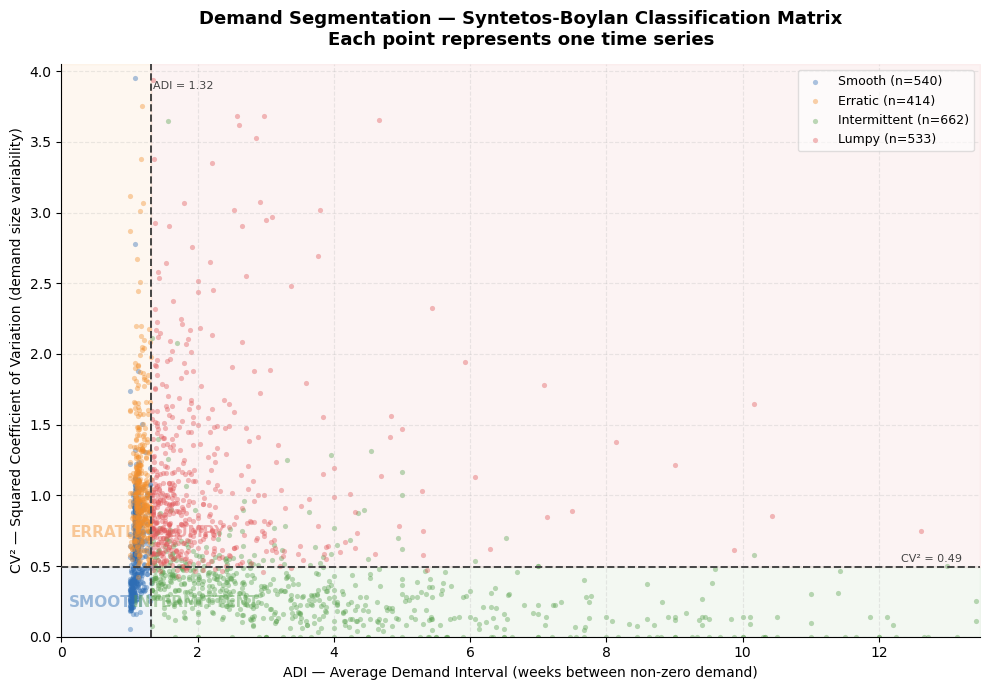

Saved: plots/slide_segmentation.png


In [89]:
ADI_THRESH = 1.32
CV2_THRESH = 0.49

# Cap axes for readability (exclude extreme outliers)
adi_max = df_sb['adi'].quantile(0.98)
cv2_max = df_sb['cv2'].quantile(0.98)
df_plot = df_sb[(df_sb['adi'] <= adi_max) & (df_sb['cv2'] <= cv2_max)]

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')

# ── Quadrant background shading ───────────────────────────────────────────────
quadrants = [
    (0,          ADI_THRESH, 0,          CV2_THRESH, '#2E6DB4', 'Smooth',       0.07),
    (0,          ADI_THRESH, CV2_THRESH, cv2_max,    '#F28E2B', 'Erratic',      0.07),
    (ADI_THRESH, adi_max,    0,          CV2_THRESH, '#59A14F', 'Intermittent', 0.07),
    (ADI_THRESH, adi_max,    CV2_THRESH, cv2_max,    '#E15759', 'Lumpy',        0.07),
]
for x0, x1, y0, y1, color, _, alpha in quadrants:
    ax.fill_betweenx([y0, y1], x0, x1, color=color, alpha=alpha)

# ── Quadrant labels ───────────────────────────────────────────────────────────
quad_labels = [
    (ADI_THRESH * 0.50, CV2_THRESH * 0.50, 'SMOOTH',       '#2E6DB4'),
    (ADI_THRESH * 0.50, CV2_THRESH * 1.50, 'ERRATIC',      '#F28E2B'),
    (ADI_THRESH * 1.50, CV2_THRESH * 0.50, 'INTERMITTENT', '#59A14F'),
    (ADI_THRESH * 1.50, CV2_THRESH * 1.50, 'LUMPY',        '#E15759'),
]
for x, y, label, color in quad_labels:
    ax.text(x, y, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color=color, alpha=0.45)

# ── Scatter — one point per series ───────────────────────────────────────────
for dt, color in DEMAND_COLORS.items():
    sub = df_plot[df_plot['demand_type'] == dt]
    ax.scatter(
        sub['adi'], sub['cv2'],
        c=color, s=14, alpha=0.40, linewidths=0,
        label=f'{dt.capitalize()} (n={len(sub):,})',
    )

# ── Threshold lines ───────────────────────────────────────────────────────────
ax.axvline(ADI_THRESH, color='#444444', linewidth=1.4, linestyle='--', zorder=5)
ax.axhline(CV2_THRESH, color='#444444', linewidth=1.4, linestyle='--', zorder=5)

ax.text(ADI_THRESH + 0.03, cv2_max * 0.97, f'ADI = {ADI_THRESH}',
        fontsize=8, color='#444444', va='top')
ax.text(adi_max * 0.98, CV2_THRESH + cv2_max * 0.01, f'CV² = {CV2_THRESH}',
        fontsize=8, color='#444444', ha='right')

ax.set_xlabel('ADI — Average Demand Interval (weeks between non-zero demand)',
              fontsize=10)
ax.set_ylabel('CV² — Squared Coefficient of Variation (demand size variability)',
              fontsize=10)
ax.set_title(
    'Demand Segmentation — Syntetos-Boylan Classification Matrix\n'
    'Each point represents one time series',
    fontsize=13, fontweight='bold', pad=14,
)
ax.legend(fontsize=9, framealpha=0.6, loc='upper right')
ax.set_xlim(0, adi_max)
ax.set_ylim(0, cv2_max)

plt.tight_layout()
plt.savefig('../../plots/slide_segmentation.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Saved: plots/slide_segmentation.png')

---
## Figure 3 — "The Problem" Extras
Four candidate charts — run each independently and decide which to keep.

| Function | What it shows |
|---|---|
| `plot_zero_cascade()` | Zero-rate per hierarchy level — sparsity appears only at the bottom |
| `plot_cv_cascade()` | CV distribution per level — volatility explodes as you disaggregate |
| `plot_ts_spaghetti()` | Overlaid sample series — visual sense of how many / how different |
| `plot_demand_heatmap()` | Series × Time heatmap — sparsity pattern at a glance |

In [97]:
# ── Shared prep for all candidate charts ─────────────────────────────────────
# df_base, df_features, df_tags already loaded in cell 2

_dm = df_tags[["unique_id", "demand_type"]].drop_duplicates()

# groupby().first() garante exatamente 1 linha por unique_id,
# independente de product_attribute_3 variar por ds no arquivo de features
_feat = (
    df_features[["unique_id", "region_id", "supplier_id", "product_attribute_1", "product_attribute_3"]]
    .groupby("unique_id", as_index=False)
    .first()
)

_df = df_base.merge(_feat, on=["unique_id",'region_id','supplier_id',"product_attribute_1", "product_attribute_3"], how="left").merge(_dm, on="unique_id", how="left")

# ── Derived date columns expected by all plot functions ───────────────────────
_df["month_date"] = _df["week_date"].dt.to_period("M").dt.to_timestamp()
_df["year"]       = _df["week_date"].dt.year

# Sanity check
n_uid = _df["unique_id"].nunique()
n_ds  = _df["ds"].nunique()
dups  = _df.duplicated(["unique_id", "ds"]).sum()
print(f"Rows: {len(_df):,}  |  Expected: {n_uid} x {n_ds} = {n_uid * n_ds:,}  |  Duplicates: {dups}")
print(f"Columns: {list(_df.columns)}")
print(f"_feat shape: {_feat.shape}  |  unique_ids: {_feat['unique_id'].nunique()}")

Rows: 203,471  |  Expected: 2841 x 52 = 147,732  |  Duplicates: 81405
Columns: ['unique_id', 'week_date', 'supplier_id', 'region_id', 'product_id', 'y', 'ds', 'start_date', 'end_date', 'year', 'semester', 'semester_date', 'semester_name', 'quarter', 'quarter_date', 'quarter_name', 'month', 'month_name', 'month_date', 'first_week_date', 'last_week_date', 'total_weeks_length', 'num_week_with_sales', 'num_week_with_zeros', 'sales_weeks_ratio', 'sales_units', 'avg_weekly_sales', 'avg_weekly_sales_non_zero', 'std_weekly_sales', 'std_weekly_sales_non_zero', 'max_weekly_sales', 'min_weekly_sales', 'q25_sales', 'q50_sales', 'q75_sales', 'iqr', 'cv', 'supplier_name', 'region_name', 'product_name', 'product_attribute_1', 'product_attribute_2', 'product_attribute_3', 'demand_type']
_feat shape: (2232, 5)  |  unique_ids: 2232


### Option A — Zero-rate cascade
**Story**: demand looks smooth at national level; sparsity only emerges at the series level.  
Each bar = % of weeks with zero sales for a given aggregation level.

Saved: ../../plots/slide_zero_cascade.png


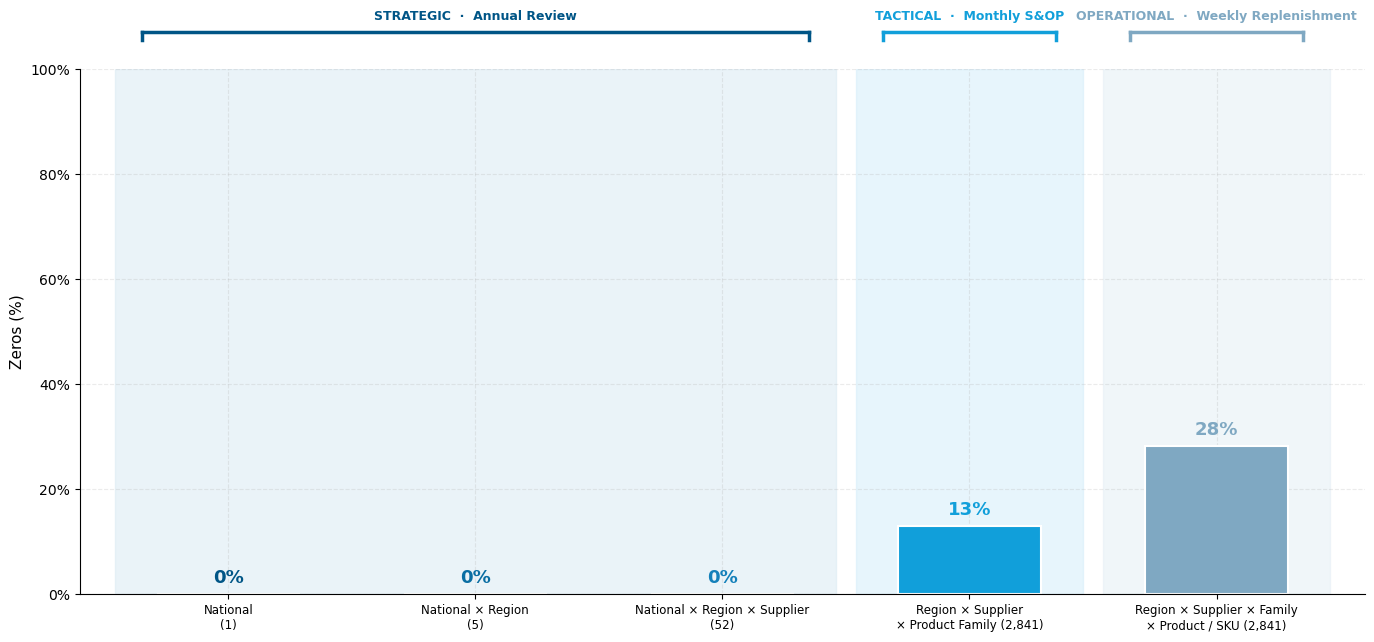

In [99]:
def plot_zero_cascade(df, save_path=None):
    """
    Zero-demand rate across planning horizons (S&OP framework).

    Strategic (Annual)  : National | National × Region | National × Region × Supplier
    Tactical  (Monthly) : Region × Supplier × Product Family (product_attribute_3)
    Operational (Weekly): Region × Supplier × Family × Product / SKU (unique_id)

    Monochromatic palette anchored on #005586 → #119FDA → #7FA8C2.
    """
    # ── Series counts ─────────────────────────────────────────────────────────
    n_region   = int(df['region_id'].nunique())
    n_sup_reg  = int(df.groupby(['region_id', 'supplier_id']).ngroups)
    n_tactical = int(df.groupby(['region_id', 'supplier_id', 'product_id']).ngroups)
    n_sku      = int(df['unique_id'].nunique())

    # ── Levels ────────────────────────────────────────────────────────────────
    LEVELS = [
        ('National\n(1)',
         df.groupby('year')['y'].sum(),
         'strategic'),
        (f'National × Region\n({n_region})',
         df.groupby(['year', 'region_id'])['y'].sum(),
         'strategic'),
        (f'National × Region × Supplier\n({n_sup_reg})',
         df.groupby(['year', 'region_id', 'supplier_id'])['y'].sum(),
         'strategic'),
        (f'Region × Supplier\n× Product Family ({n_tactical:,})',
         df.groupby(['month_date', 'region_id', 'supplier_id', 'product_id'])['y'].sum(),
         'tactical'),
        (f'Region × Supplier × Family\n× Product / SKU ({n_sku:,})',
         df.groupby(['ds', 'unique_id'])['y'].sum(),
         'operational'),
    ]
    zero_rates = [(lbl, float((ser == 0).mean()), grp) for lbl, ser, grp in LEVELS]

    # ── Monochromatic palette: #005586 → #119FDA → #7FA8C2 ───────────────────
    PLAN_STYLE = {
        'strategic':   {
            'colors':  ['#005586', '#0A6EA3', '#1480BA'],  # 3 shades for 3 bars
            'bg':      '#D9EAF3',
            'label':   'STRATEGIC',
            'freq':    'Annual Review',
            'anchor':  '#005586',
        },
        'tactical':    {
            'colors':  ['#119FDA'],
            'bg':      '#D4EDFB',
            'label':   'TACTICAL',
            'freq':    'Monthly S&OP',
            'anchor':  '#119FDA',
        },
        'operational': {
            'colors':  ['#7FA8C2'],
            'bg':      '#E5EFF5',
            'label':   'OPERATIONAL',
            'freq':    'Weekly Replenishment',
            'anchor':  '#7FA8C2',
        },
    }

    GROUPS = [
        ('strategic',   [0, 1, 2]),
        ('tactical',    [3]),
        ('operational', [4]),
    ]

    # ── Color assignment per bar ──────────────────────────────────────────────
    bar_colors = []
    group_idx  = {grp: 0 for grp in PLAN_STYLE}
    for _, _, grp in zero_rates:
        palette = PLAN_STYLE[grp]['colors']
        bar_colors.append(palette[group_idx[grp] % len(palette)])
        group_idx[grp] += 1

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6.5))
    fig.patch.set_facecolor('white')

    # Shaded backgrounds
    for grp_key, idxs in GROUPS:
        ax.axvspan(min(idxs) - 0.46, max(idxs) + 0.46,
                   color=PLAN_STYLE[grp_key]['bg'], alpha=0.55, zorder=0)

    # Bars
    positions = list(range(len(zero_rates)))
    for pos, (lbl, rate, grp), color in zip(positions, zero_rates, bar_colors):
        ax.bar(pos, rate, color=color, width=0.58,
               edgecolor='white', linewidth=1.5, zorder=2)
        ax.text(pos, rate + 0.014, f'{rate:.0%}',
                ha='center', va='bottom',
                fontsize=13, fontweight='bold', color=color)

    # Brackets above bars
    bracket_y = 1.07
    for grp_key, idxs in GROUPS:
        style = PLAN_STYLE[grp_key]
        x0, x1 = min(idxs) - 0.35, max(idxs) + 0.35
        xmid   = (x0 + x1) / 2

        ax.plot([x0, x1], [bracket_y, bracket_y],
                color=style['anchor'], linewidth=2.5,
                transform=ax.get_xaxis_transform(), clip_on=False)
        for xc in [x0, x1]:
            ax.plot([xc, xc], [bracket_y - 0.014, bracket_y],
                    color=style['anchor'], linewidth=2.5,
                    transform=ax.get_xaxis_transform(), clip_on=False)
        ax.text(xmid, bracket_y + 0.018,
                f'{style["label"]}  ·  {style["freq"]}',
                ha='center', va='bottom', fontsize=9,
                fontweight='bold', color=style['anchor'],
                transform=ax.get_xaxis_transform(), clip_on=False)

    # Axes
    ax.set_xticks(positions)
    ax.set_xticklabels([z[0] for z in zero_rates], fontsize=8.5)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_ylabel('Zeros (%)', fontsize=11)
    ax.set_xlim(-0.6, len(zero_rates) - 0.4)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


plot_zero_cascade(_df, save_path='../../plots/slide_zero_cascade.png')

### Option B — CV cascade (volatility fan)
**Story**: as you disaggregate, the coefficient of variation explodes — upper hierarchy effects don't cancel out, they amplify intermittency.  
Each level shows the distribution of CV across all entities at that level.

Saved: ../../plots/slide_cv_cascade.png


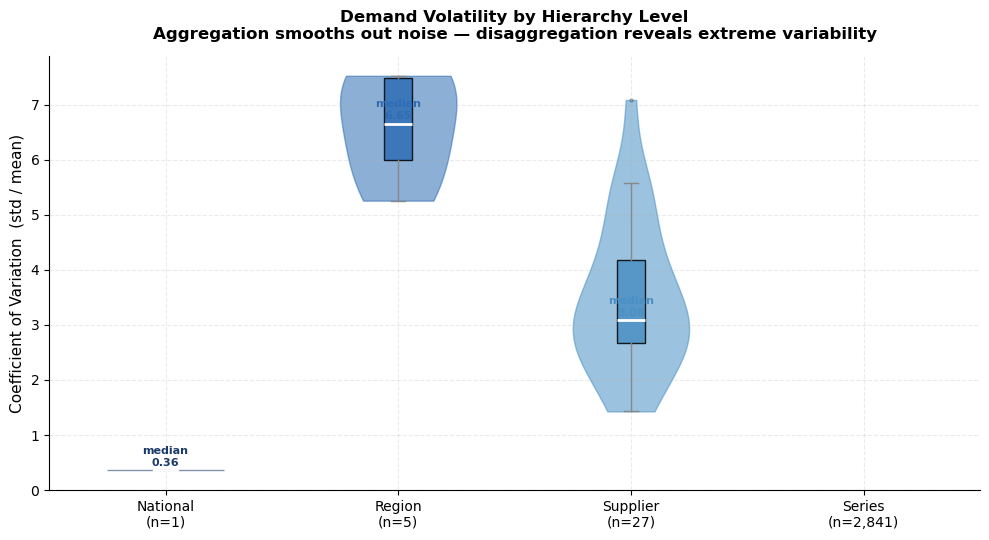

In [100]:
def plot_cv_cascade(df, save_path=None):
    """
    Violin + box plot showing CV (std/mean) distribution at each hierarchy level.
    Only uses weeks with mean > 0 to avoid division by zero.
    """
    def cvs_for_group(grouped):
        cvs = []
        for _, g in grouped:
            weekly = g['y'].values
            m = weekly.mean()
            if m > 0:
                cvs.append(weekly.std() / m)
        return cvs

    levels_cv = {
        'National':   cvs_for_group(df.groupby('ds')[['y']].apply(lambda x: x).groupby(level=0)),
        'Region':     cvs_for_group(df.groupby('region_id')),
        'Supplier':   cvs_for_group(df.groupby('supplier_id')),
        'Series':     cvs_for_group(df.groupby('unique_id')),
    }
    # National is a single number — compute directly
    nat = df.groupby('ds')['y'].sum()
    levels_cv['National'] = [nat.std() / nat.mean()] if nat.mean() > 0 else [0]

    labels  = list(levels_cv.keys())
    data    = [levels_cv[l] for l in labels]
    colors  = ['#1B3A6B', '#2E6DB4', '#4A90C4', '#6EB5D8']
    medians = [np.median(d) for d in data]

    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.patch.set_facecolor('white')

    parts = ax.violinplot(data, positions=range(len(labels)),
                          showmedians=False, showextrema=False)
    for i, (pc, color) in enumerate(zip(parts['bodies'], colors)):
        pc.set_facecolor(color)
        pc.set_alpha(0.55)
        pc.set_edgecolor(color)

    bp = ax.boxplot(data, positions=range(len(labels)),
                    widths=0.12, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888888'),
                    capprops=dict(color='#888888'),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='#aaaaaa'))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    for i, med in enumerate(medians):
        ax.text(i, med + 0.05, f'median\n{med:.2f}',
                ha='center', va='bottom', fontsize=8,
                fontweight='bold', color=colors[i])

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(
        [f'{l}\n(n={len(data[i]):,})' for i, l in enumerate(labels)],
        fontsize=10,
    )
    ax.set_ylabel('Coefficient of Variation  (std / mean)', fontsize=11)
    ax.set_title(
        'Demand Volatility by Hierarchy Level\n'
        'Aggregation smooths out noise — disaggregation reveals extreme variability',
        fontsize=12, fontweight='bold', pad=12,
    )
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


plot_cv_cascade(_df, save_path='../../plots/slide_cv_cascade.png')

### Option C — Time series spaghetti
**Story**: 2,232 series look like this — visually overwhelming, each with its own pattern.  
Sample of series overlaid per demand type. Shows the scale of the problem.

Saved: ../../plots/slide_spaghetti.png


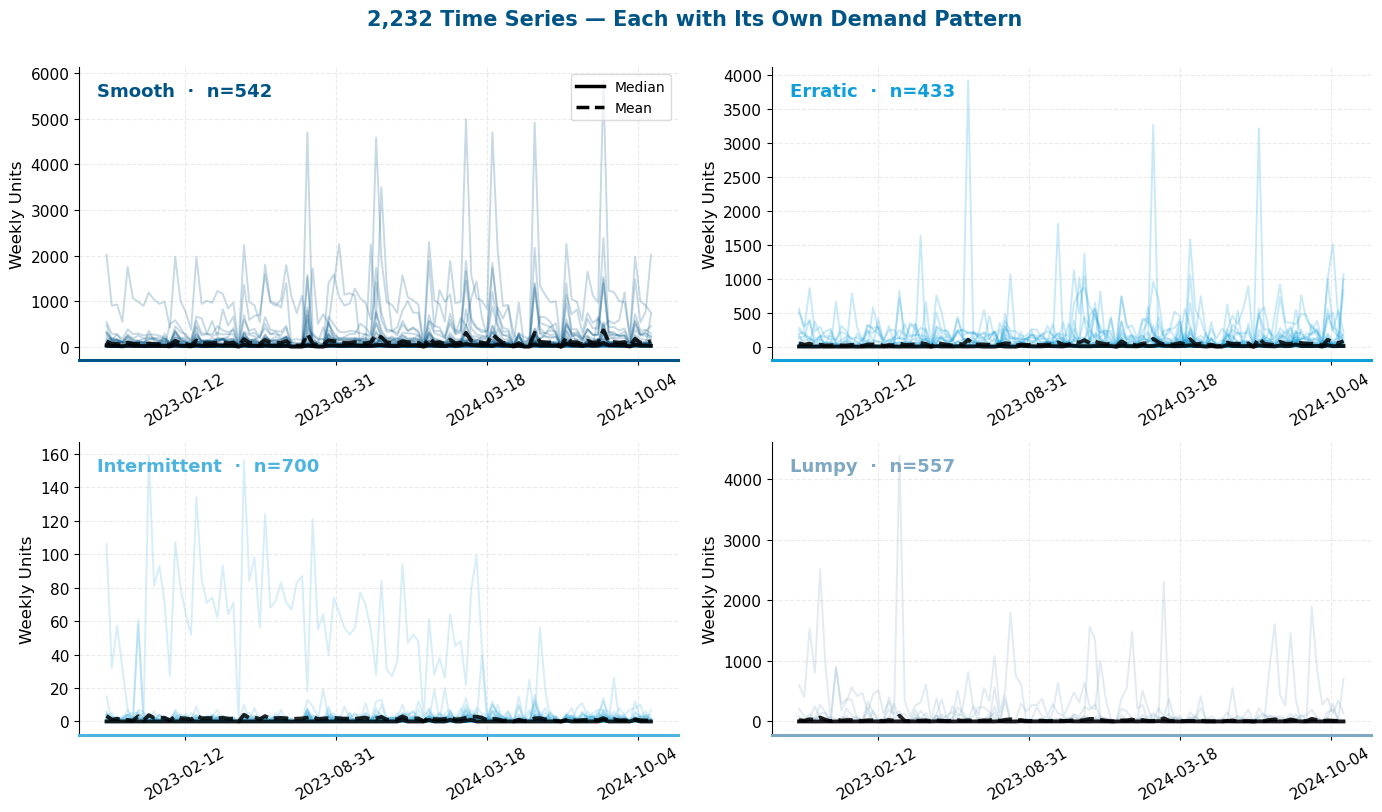

In [104]:
def plot_ts_spaghetti(df, n_per_type=40, seed=42, save_path=None):
    """
    2×2 spaghetti plot: one panel per demand type, n_per_type series overlaid.
    Monochromatic palette: #005586 → #119FDA → #4DB4E0 → #7FA8C2 (dark to light).
    Mean and median lines in black.
    """
    rng = np.random.default_rng(seed)
    demand_order = ['smooth', 'erratic', 'intermittent', 'lumpy']
    weeks = sorted(df['week_date'].unique())

    MONO_COLORS = {
        'smooth':       '#005586',
        'erratic':      '#119FDA',
        'intermittent': '#4DB4E0',
        'lumpy':        '#7FA8C2',
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.patch.set_facecolor('white')
    axes_flat = axes.flatten()

    for ax, dt in zip(axes_flat, demand_order):
        color  = MONO_COLORS[dt]
        uids   = df[df['demand_type'] == dt]['unique_id'].unique()
        sample = rng.choice(uids, size=min(n_per_type, len(uids)), replace=False)

        pivot = (
            df[df['unique_id'].isin(sample)]
            .pivot_table(index='week_date', columns='unique_id', values='y', fill_value=0)
            .reindex(weeks, fill_value=0)
        )

        # Individual series
        for uid in pivot.columns:
            ax.plot(pivot.index, pivot[uid], color=color,
                    linewidth=1.4, alpha=0.22)

        # Mean and median in black
        mean_ts   = pivot.mean(axis=1)
        median_ts = pivot.median(axis=1)

        ax.plot(pivot.index, median_ts, color='black',
                linewidth=2.8, alpha=0.85, linestyle='-',  label='Median')
        ax.plot(pivot.index, mean_ts, color='black',
                linewidth=2.8, alpha=0.85, linestyle='--', label='Mean')

        # Label inside panel
        ax.text(0.03, 0.95, f'{dt.capitalize()}  ·  n={len(uids):,}',
                transform=ax.transAxes, ha='left', va='top',
                fontsize=13, fontweight='bold', color=color)

        ax.tick_params(axis='x', rotation=30, labelsize=11)
        ax.tick_params(axis='y', labelsize=11)
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
        ax.set_ylabel('Weekly Units', fontsize=12)

        ax.spines['bottom'].set_color(color)
        ax.spines['bottom'].set_linewidth(2.2)

    # Shared legend (only on first axis)
    axes_flat[0].legend(
        fontsize=10, framealpha=0.7, loc='upper right',
        handles=[
            plt.Line2D([0], [0], color='black', lw=2.5, linestyle='-',  label='Median'),
            plt.Line2D([0], [0], color='black', lw=2.5, linestyle='--', label='Mean'),
        ]
    )

    fig.suptitle(
        '2,232 Time Series — Each with Its Own Demand Pattern',
        fontsize=15, fontweight='bold', y=1.01,
        color='#005586',
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


plot_ts_spaghetti(_df, n_per_type=50, save_path='../../plots/slide_spaghetti.png')

---
## Figure — EDA
**Slide: Exploratory Data Analysis**

Regional longitudinal trends aggregated by month — two panels:
- **Left**: total monthly volume per region (stacked area) — shows scale differences that justify region-aware models
- **Right**: indexed trend (first non-zero month = 100) — reveals shared macro dynamics across regions

*(Zero-inflation and demand heterogeneity are covered in the Problem slides; EDA focuses on regional structure and temporal patterns.)*

Saved: ../../plots/slide_regional_trends.png


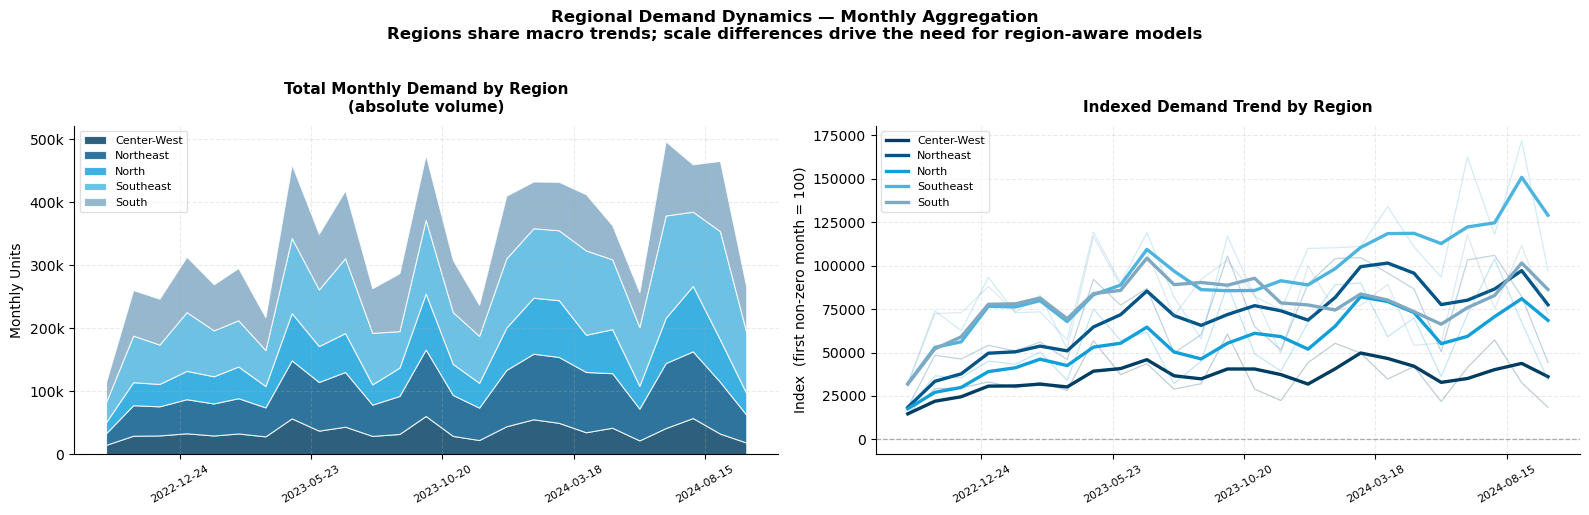

In [109]:
def plot_regional_trends(df, save_path=None):
    """
    Two-panel longitudinal chart aggregated by region, monthly.

    Panel A — Absolute volume: total monthly units per region (stacked area).
    Panel B — Indexed trend (base = first non-zero month = 100).
    Palette: monochromatic blues #003D60 → #005586 → #119FDA → #4DB4E0 → #7FA8C2
    """
    # Monochromatic 5-shade palette — self-contained, no global dependency
    PALETTE = ['#003D60', '#005586', '#119FDA', '#4DB4E0', '#7FA8C2']

    region_labels = {
        1: 'Center-West', 2: 'Northeast', 3: 'North',
        4: 'Southeast',   5: 'South',
    }

    df_m = (
        df.assign(month_dt=df['week_date'].dt.to_period('M').dt.to_timestamp())
        .groupby(['month_dt', 'region_id'], observed=True)['y']
        .sum()
        .reset_index()
    )

    regions = sorted(df_m['region_id'].dropna().unique())
    colors  = PALETTE[:len(regions)]

    monthly = {}
    for rid in regions:
        lbl = region_labels.get(int(rid), f'Region {int(rid)}')
        monthly[lbl] = (
            df_m[df_m['region_id'] == rid]
            .sort_values('month_dt')
            .set_index('month_dt')['y']
        )

    dates         = sorted({dt for s in monthly.values() for dt in s.index})
    labels_ordered = [region_labels[int(r)] for r in regions]
    stack_data     = np.array([
        monthly[lbl].reindex(dates, fill_value=0).values
        for lbl in labels_ordered
    ])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.patch.set_facecolor('white')

    # ── Panel A: Stacked area ─────────────────────────────────────────────────
    ax = axes[0]
    polys = ax.stackplot(dates, stack_data, labels=labels_ordered,
                         colors=colors, alpha=0.82)
    # White border between layers for better separation
    for poly in polys:
        poly.set_edgecolor('white')
        poly.set_linewidth(0.8)

    ax.set_title('Total Monthly Demand by Region\n(absolute volume)',
                 fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel('Monthly Units', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.xaxis.set_major_locator(plt.MaxNLocator(8))
    ax.legend(fontsize=8, loc='upper left', framealpha=0.6)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k' if v >= 1000 else f'{v:.0f}')
    )

    # ── Panel B: Indexed trend ────────────────────────────────────────────────
    ax2 = axes[1]
    for rid, color in zip(regions, colors):
        lbl = region_labels[int(rid)]
        ser = monthly[lbl].reindex(dates, fill_value=0)

        positives = ser[ser > 0]
        #base = positives.iloc[0] if not positives.empty else 1
        idx  = ser #(ser / base) * 100

        # Faint raw line + smoothed (rolling 3-month) foreground
        ax2.plot(dates, idx,
                 color=color, linewidth=0.9, alpha=0.25)
        ax2.plot(dates, idx.rolling(3, min_periods=1).mean(),
                 color=color, linewidth=2.4, label=lbl)

    ax2.axhline(100, color='#aaaaaa', linewidth=0.9, linestyle='--')
    ax2.set_title('Indexed Demand Trend by Region',
                  fontsize=11, fontweight='bold', pad=10)
    ax2.set_ylabel('Index  (first non-zero month = 100)', fontsize=10)
    ax2.tick_params(axis='x', rotation=30, labelsize=8)
    ax2.xaxis.set_major_locator(plt.MaxNLocator(8))
    ax2.legend(fontsize=8, loc='upper left', framealpha=0.6)

    fig.suptitle(
        'Regional Demand Dynamics — Monthly Aggregation\n'
        'Regions share macro trends; scale differences drive the need for region-aware models',
        fontsize=12, fontweight='bold', y=1.02,
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


plot_regional_trends(_df, save_path='../../plots/slide_regional_trends.png')

In [105]:
df_m = (
        _df.assign(month_dt=_df['week_date'].dt.to_period('M').dt.to_timestamp())
        .groupby(['month_dt', 'region_id'], observed=True)['y']
        .sum()
        .reset_index()
    )

In [107]:
df_m[['month_dt']].drop_duplicates()

,month_dt
0,2022-10-01
5,2022-11-01
10,2022-12-01
15,2023-01-01
20,2023-02-01
25,2023-03-01
30,2023-04-01
35,2023-05-01
40,2023-06-01
45,2023-07-01


In [76]:
# Monochromatic 5-shade palette — self-contained, no global dependency
PALETTE = ['#003D60', '#005586', '#119FDA', '#4DB4E0', '#7FA8C2']

region_labels = {
    1: 'Center-West', 2: 'Northeast', 3: 'North',
    4: 'Southeast',   5: 'South',
}

regions = sorted(df_m['region_id'].dropna().unique())
colors  = PALETTE[:len(regions)]

monthly = {}
for rid in regions:
    lbl = region_labels.get(int(rid), f'Region {int(rid)}')
    monthly[lbl] = (
        df_m[df_m['region_id'] == rid]
        .sort_values('month_dt')
        .set_index('month_dt')['y']
    )


In [77]:
dates         = sorted({dt for s in monthly.values() for dt in s.index})
labels_ordered = [region_labels[int(r)] for r in regions]
stack_data     = np.array([
monthly[lbl].reindex(dates, fill_value=0).values
for lbl in labels_ordered
])

In [73]:
df_m

,month_dt,region_id,y
0,1970-01-01,1,904930
1,1970-01-01,2,1775126
2,1970-01-01,3,1399256
3,1970-01-01,4,2426173
4,1970-01-01,5,2011689


### EDA — Train/test cutoff · MSTL decomposition · ACF · Outliers

Four complementary figures for the EDA slide.  
All operate on the **national aggregate** weekly series for a cleaner signal.

IndexError: single positional indexer is out-of-bounds

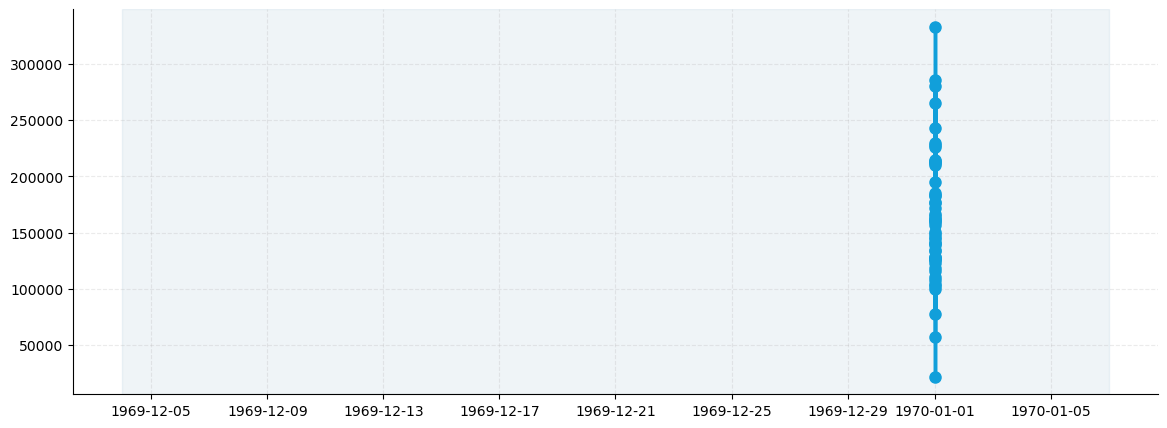

In [65]:
def plot_eda_cutoff(df, horizon=4, save_path=None):
    """
    National aggregate with train/test split highlighted.
    Shows the 4-week forecast horizon used for model evaluation.
    """
    agg = (
        df.groupby('week_date')['y'].sum()
        .reset_index().sort_values('week_date')
    )
    cutoff = agg['week_date'].max() - pd.Timedelta(weeks=horizon)
    train  = agg[agg['week_date'] <= cutoff]
    test   = agg[agg['week_date'] >  cutoff]

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('white')

    # Shaded test zone
    ax.axvspan(cutoff, agg['week_date'].max() + pd.Timedelta(days=6),
               color='#7FA8C2', alpha=0.12, label='Test zone')

    # Series
    ax.plot(train['week_date'], train['y'],
            color='#005586', lw=2.2, label=f'Train  ({len(train)} weeks)')
    ax.plot(test['week_date'],  test['y'],
            color='#119FDA', lw=2.5, marker='o', markersize=8,
            label=f'Test  ({horizon} weeks — forecast horizon)')
    # Bridge gap
    ax.plot([train['week_date'].iloc[-1], test['week_date'].iloc[0]],
            [train['y'].iloc[-1],          test['y'].iloc[0]],
            color='#119FDA', lw=2.5, linestyle='--')

    # Cutoff line
    ax.axvline(cutoff, color='#333333', lw=1.5, linestyle='--', alpha=0.7)
    ax.text(cutoff + pd.Timedelta(days=2),
            agg['y'].quantile(0.95),
            f'Cutoff\n{cutoff.strftime("%b %d, %Y")}',
            fontsize=9, color='#333333', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#aaaaaa', alpha=0.85))

    ax.set_ylabel('National Weekly Units', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.legend(fontsize=10, framealpha=0.6)
    ax.set_title(
        'Train / Test Split — National Aggregate\n'
        f'Evaluation window: last {horizon} weeks  ·  Walk-forward CV with 6 windows',
        fontsize=12, fontweight='bold', pad=12,
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


plot_eda_cutoff(_df, save_path='../../plots/slide_eda_cutoff.png')

Saved: ../../plots/slide_eda_decomposition.png


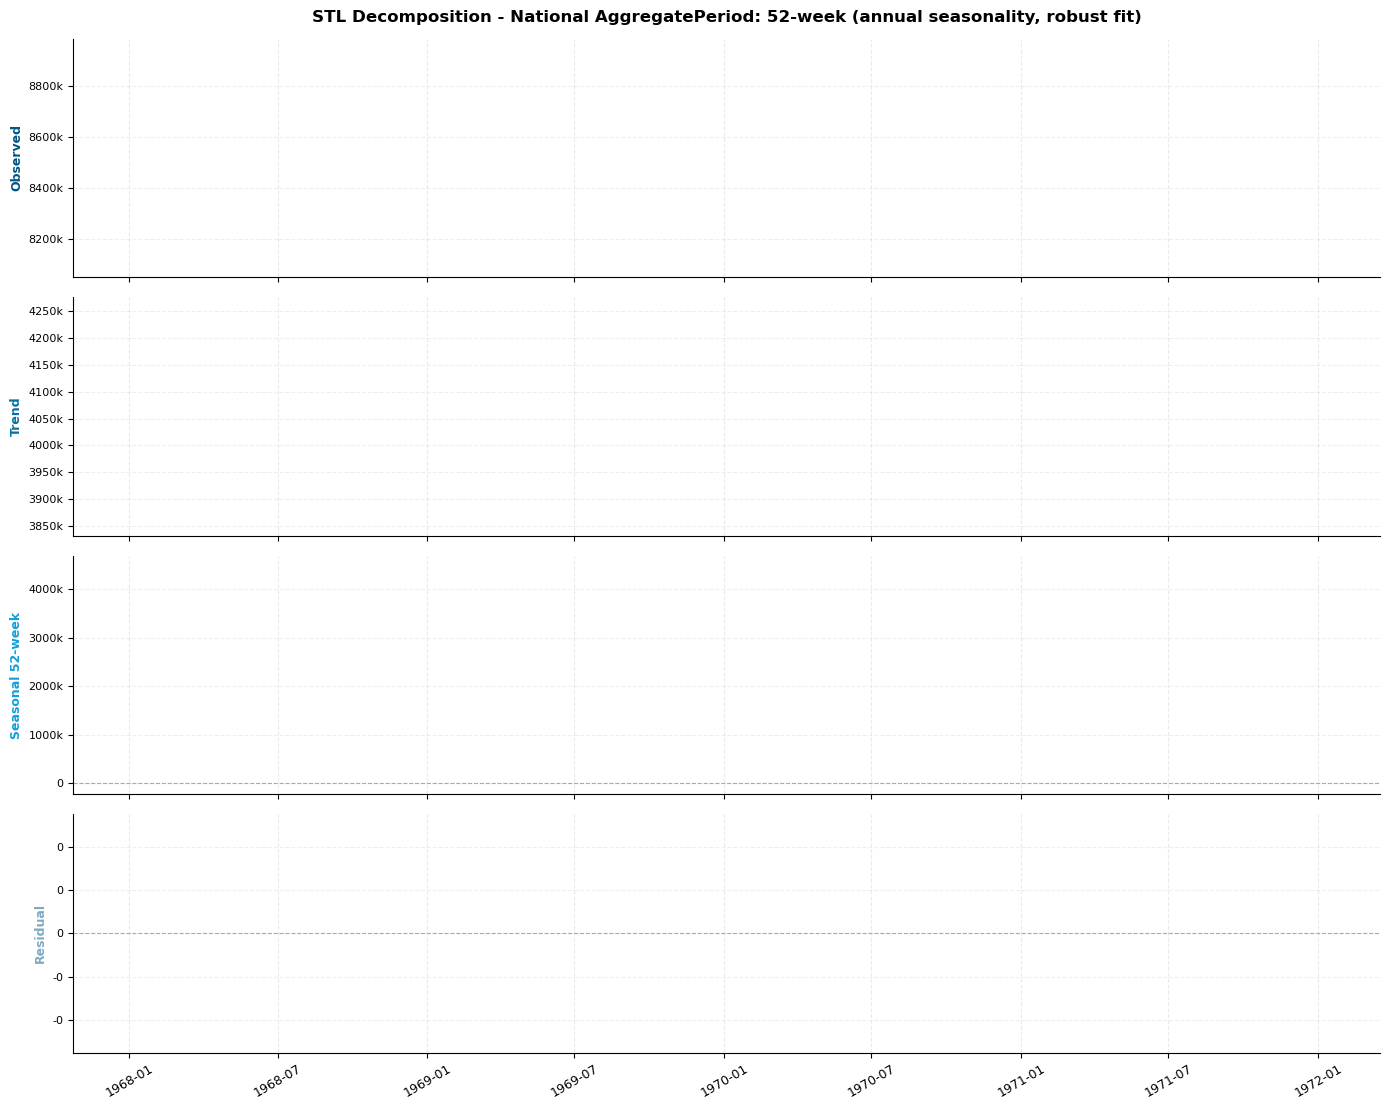

In [64]:
def plot_eda_decomposition(df, save_path=None):
    """
    STL decomposition of national aggregate (period=52 weeks, annual seasonality).
    Justifies seasonal lag features in the model.
    """
    from statsmodels.tsa.seasonal import STL

    agg = (
        df.groupby('week_date')['y'].sum()
        .reset_index().sort_values('week_date')
        .set_index('week_date')['y']
    )
    agg.index = pd.to_datetime(agg.index)
    agg = agg.resample('W').sum()   # regular weekly freq; fills any gaps with 0

    result = STL(agg, period=52, robust=True).fit()

    components = [
        ('Observed',        pd.Series(agg.values,         index=agg.index), '#005586'),
        ('Trend',           pd.Series(result.trend,       index=agg.index), '#0A6EA3'),
        ('Seasonal 52-week',pd.Series(result.seasonal,    index=agg.index), '#119FDA'),
        ('Residual',        pd.Series(result.resid,       index=agg.index), '#7FA8C2'),
    ]

    n = len(components)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.8 * n), sharex=True)
    fig.patch.set_facecolor('white')

    for ax, (name, series, color) in zip(axes, components):
        ax.plot(series.index, series.values, color=color, lw=1.8)
        ax.set_ylabel(name, fontsize=9, fontweight='bold', color=color)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(axis='y', alpha=0.2, linestyle='--')
        if 'Seasonal' in name or name == 'Residual':
            ax.axhline(0, color='#aaaaaa', lw=0.8, linestyle='--')
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k' if abs(v) >= 1000 else f'{v:.0f}')
        )

    axes[-1].tick_params(axis='x', rotation=30, labelsize=9)
    axes[0].set_title(
        'STL Decomposition - National Aggregate'
        'Period: 52-week (annual seasonality, robust fit)',
        fontsize=12, fontweight='bold', pad=12,
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


plot_eda_decomposition(_df, save_path='../../plots/slide_eda_decomposition.png')

Saved: ../../plots/slide_eda_acf.png


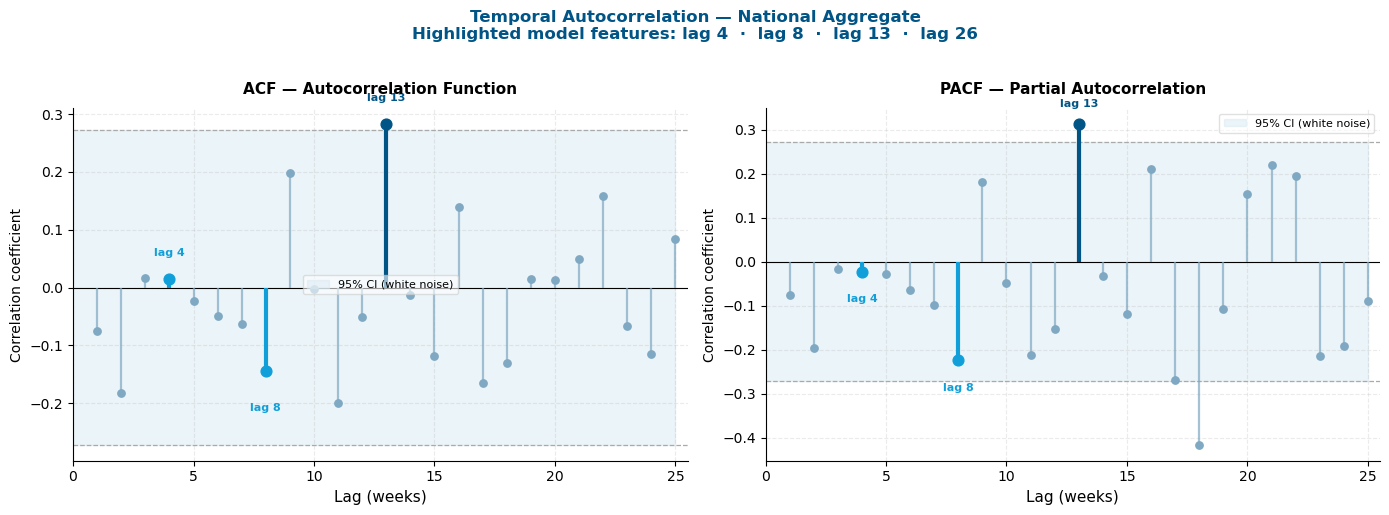

In [57]:
def plot_eda_acf(df, model_lags=(4, 8, 13, 26), nlags=28, save_path=None):
    """
    ACF + PACF of national aggregate.
    model_lags: highlights the exact lags used as model features (medium preset).
    Two panels side by side — ACF shows persistence, PACF shows direct effects.
    """
    from statsmodels.tsa.stattools import acf, pacf

    agg = (
        df.groupby('week_date')['y'].sum()
        .reset_index().sort_values('week_date')['y']
        .values.astype(float)
    )

    n = len(agg)
    nlags_safe = min(nlags, n // 2 - 1)

    acf_vals,  acf_ci  = acf( agg, nlags=nlags_safe, alpha=0.05)
    pacf_vals, pacf_ci = pacf(agg, nlags=nlags_safe, alpha=0.05)

    lags = np.arange(nlags_safe + 1)
    ci_bound = 1.96 / np.sqrt(n)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.patch.set_facecolor('white')

    for ax, vals, ci, title in [
        (axes[0], acf_vals,  acf_ci,  'ACF — Autocorrelation Function'),
        (axes[1], pacf_vals, pacf_ci, 'PACF — Partial Autocorrelation'),
    ]:
        ax.fill_between(lags, ci_bound, -ci_bound,
                        color='#D9EAF3', alpha=0.5, label='95% CI (white noise)')
        ax.axhline( ci_bound, color='#aaaaaa', lw=0.9, linestyle='--')
        ax.axhline(-ci_bound, color='#aaaaaa', lw=0.9, linestyle='--')
        ax.axhline(0,         color='black',   lw=0.8)

        ax.vlines(lags[1:], 0, vals[1:], color='#7FA8C2', lw=1.6, alpha=0.7)
        ax.scatter(lags[1:], vals[1:], s=28, color='#7FA8C2', zorder=4)

        for lag in model_lags:
            if lag <= nlags_safe:
                val = vals[lag]
                color = '#005586' if abs(val) > ci_bound else '#119FDA'
                ax.vlines(lag, 0, val, color=color, lw=3, zorder=5)
                ax.scatter(lag, val, s=60, color=color, zorder=6)
                ax.text(lag, val + (0.04 if val >= 0 else -0.07),
                        f'lag {lag}', ha='center', fontsize=8,
                        fontweight='bold', color=color)

        ax.set_xlabel('Lag (weeks)', fontsize=11)
        ax.set_ylabel('Correlation coefficient', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
        ax.set_xlim(0, nlags_safe + 0.5)
        ax.legend(fontsize=8, framealpha=0.6)

    lag_str = '  ·  '.join(f'lag {l}' for l in model_lags)
    fig.suptitle(
        f'Temporal Autocorrelation — National Aggregate\n'
        f'Highlighted model features: {lag_str}',
        fontsize=12, fontweight='bold', y=1.02, color='#005586',
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


plot_eda_acf(_df, save_path='../../plots/slide_eda_acf.png')

Saved: ../../plots/slide_eda_lag_selection.png


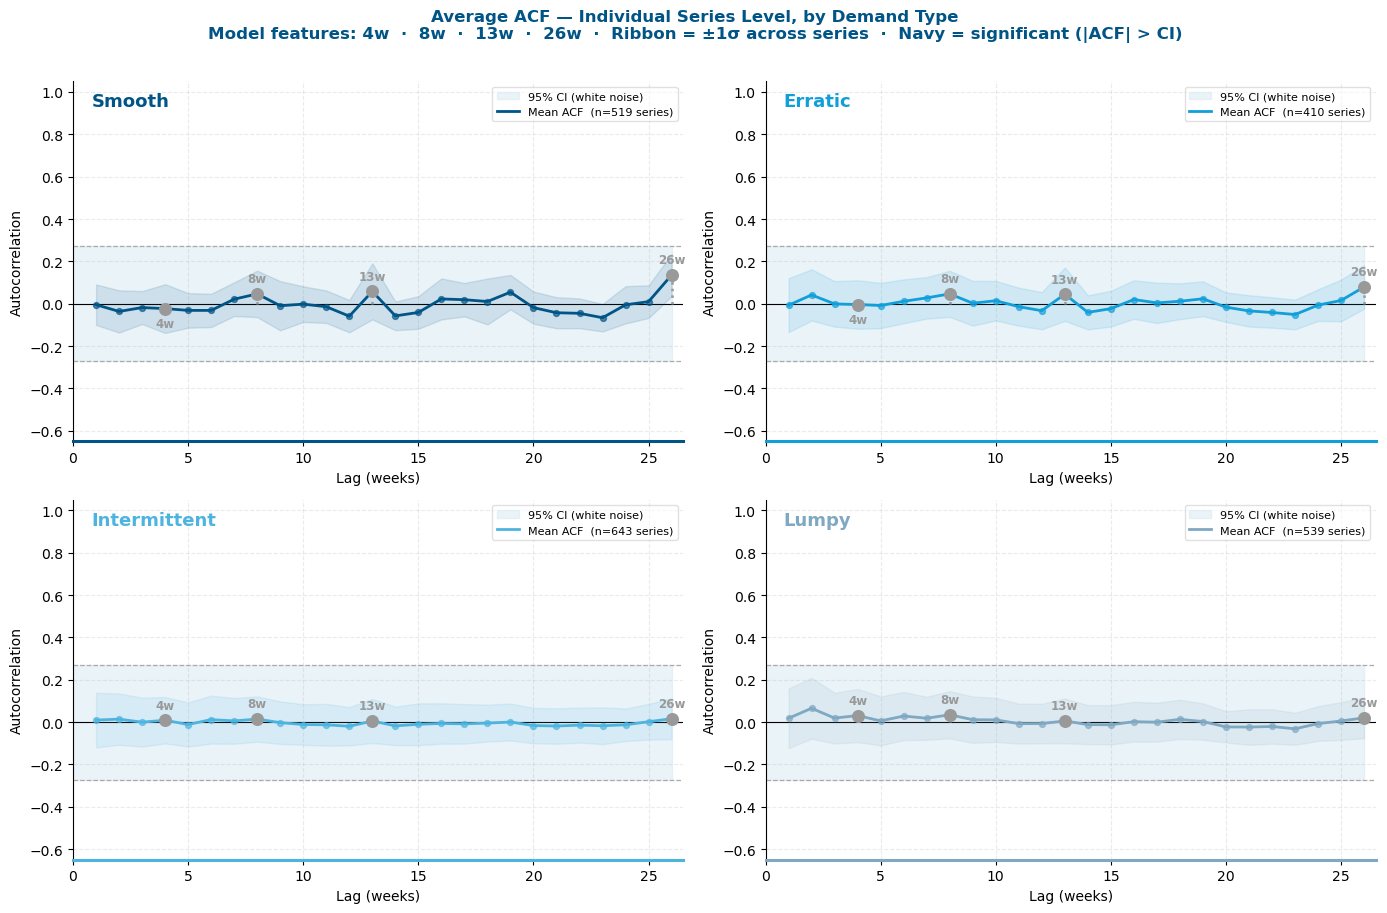

White-noise CI: ±0.272  (1.96 / √52)

 Lag        smooth       erratic    intermitte         lumpy
------------------------------------------------------------
   4w  -0.023         -0.004         +0.009         +0.031       
   8w  +0.047         +0.047         +0.014         +0.034       
  13w  +0.059         +0.045         +0.005         +0.005       
  26w  +0.136         +0.079         +0.016         +0.020       


In [58]:
def plot_eda_avg_acf(df, model_lags=(4, 8, 13, 26), nlags=26, min_obs=20, save_path=None):
    """
    Average ACF across individual series, one panel per demand type.

    Why this is more rigorous than national-aggregate ACF:
      - The model is trained on individual series, not the aggregate
      - Averaging across series reduces noise and shows the structural pattern
      - Ribbon = ±1 std across series → shows how consistent the pattern is
      - Highlighted lags above CI → justified as model features
      - Highlighted lags below CI → present but not dominant (still can help)

    Justification logic (for the slide narrative):
      If mean ACF at lag k is above the white-noise CI band → that lag carries
      predictive information at the series level → using it as a model feature
      is empirically motivated.
    """
    from statsmodels.tsa.stattools import acf as compute_acf

    demand_order = ['smooth', 'erratic', 'intermittent', 'lumpy']
    MONO = {
        'smooth':       '#005586',
        'erratic':      '#119FDA',
        'intermittent': '#4DB4E0',
        'lumpy':        '#7FA8C2',
    }

    n_weeks  = df['ds'].nunique()
    ci_bound = 1.96 / np.sqrt(n_weeks)   # white-noise threshold per series

    # ── Compute per-series ACF and aggregate ──────────────────────────────────
    acf_stats = {}
    for dt in demand_order:
        uids = df[df['demand_type'] == dt]['unique_id'].unique()
        acf_matrix = []
        for uid in uids:
            y = (
                df[df['unique_id'] == uid]
                .sort_values('ds')['y']
                .values.astype(float)
            )
            if len(y) < min_obs:
                continue
            safe = min(nlags, len(y) // 2 - 1)
            try:
                a = compute_acf(y, nlags=safe, fft=True)
                # pad with NaN if shorter than requested nlags
                if len(a) < nlags + 1:
                    a = np.pad(a, (0, nlags + 1 - len(a)),
                               constant_values=np.nan)
                acf_matrix.append(a[:nlags + 1])
            except Exception:
                pass

        if acf_matrix:
            mat = np.array(acf_matrix)
            acf_stats[dt] = {
                'mean': np.nanmean(mat, axis=0),
                'std':  np.nanstd(mat,  axis=0),
                'n':    mat.shape[0],
            }

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.patch.set_facecolor('white')
    lags_arr = np.arange(nlags + 1)

    for ax, dt in zip(axes.flatten(), demand_order):
        color = MONO[dt]
        stats = acf_stats.get(dt)
        if stats is None:
            ax.text(0.5, 0.5, f'No data — {dt}',
                    ha='center', va='center', transform=ax.transAxes)
            continue

        mean_acf = stats['mean']
        std_acf  = stats['std']
        n_series = stats['n']

        # White-noise CI band
        ax.fill_between(lags_arr, ci_bound, -ci_bound,
                        color='#D9EAF3', alpha=0.55, zorder=1,
                        label='95% CI (white noise)')
        ax.axhline( ci_bound, color='#aaaaaa', lw=0.9, linestyle='--')
        ax.axhline(-ci_bound, color='#aaaaaa', lw=0.9, linestyle='--')
        ax.axhline(0, color='black', lw=0.8)

        # ±1 std ribbon across series
        ax.fill_between(lags_arr[1:],
                        mean_acf[1:] - std_acf[1:],
                        mean_acf[1:] + std_acf[1:],
                        color=color, alpha=0.12, zorder=2)

        # Mean ACF line
        ax.plot(lags_arr[1:], mean_acf[1:],
                color=color, lw=2.0, zorder=4,
                label=f'Mean ACF  (n={n_series:,} series)')
        ax.scatter(lags_arr[1:], mean_acf[1:],
                   s=18, color=color, zorder=5, alpha=0.65)

        # Highlight model lags — navy if above CI, grey if below
        for lag in model_lags:
            if lag > nlags:
                continue
            val = mean_acf[lag]
            is_sig = abs(val) > ci_bound
            c      = '#005586' if is_sig else '#999999'
            lw     = 3.0  if is_sig else 1.8
            ls     = '-'  if is_sig else ':'
            ax.vlines(lag, 0, val, color=c, lw=lw, linestyle=ls, zorder=6)
            ax.scatter(lag, val, s=70, color=c, zorder=7)
            ax.text(lag,
                    val + (0.055 if val >= 0 else -0.085),
                    f'{lag}w',
                    ha='center', fontsize=8.5, fontweight='bold', color=c)

        # Demand type label
        ax.text(0.03, 0.97, f'{dt.capitalize()}',
                transform=ax.transAxes, ha='left', va='top',
                fontsize=13, fontweight='bold', color=color)

        ax.set_xlabel('Lag (weeks)', fontsize=10)
        ax.set_ylabel('Autocorrelation', fontsize=10)
        ax.set_xlim(0, nlags + 0.5)
        ax.set_ylim(-0.65, 1.05)
        ax.legend(fontsize=8, framealpha=0.6, loc='upper right')
        ax.spines['bottom'].set_color(color)
        ax.spines['bottom'].set_linewidth(2.2)

    lag_str = '  ·  '.join(f'{l}w' for l in model_lags)
    fig.suptitle(
        f'Average ACF — Individual Series Level, by Demand Type\n'
        f'Model features: {lag_str}  ·  Ribbon = ±1σ across series  ·  '
        f'Navy = significant (|ACF| > CI)',
        fontsize=12, fontweight='bold', y=1.01, color='#005586',
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()

    # Summary table
    print(f'White-noise CI: ±{ci_bound:.3f}  (1.96 / √{n_weeks})\n')
    header = f'{"Lag":>4}' + ''.join(f'  {dt[:10]:>12}' for dt in demand_order)
    print(header)
    print('-' * len(header))
    for lag in model_lags:
        row = f'{lag:>4}w'
        for dt in demand_order:
            if dt in acf_stats:
                val = acf_stats[dt]['mean'][lag]
                sig = '✓' if abs(val) > ci_bound else ' '
                row += f'  {val:+.3f} {sig}     '
        print(row)


plot_eda_avg_acf(_df, save_path='../../plots/slide_eda_lag_selection.png')

Saved: ../../plots/slide_eda_outliers.png


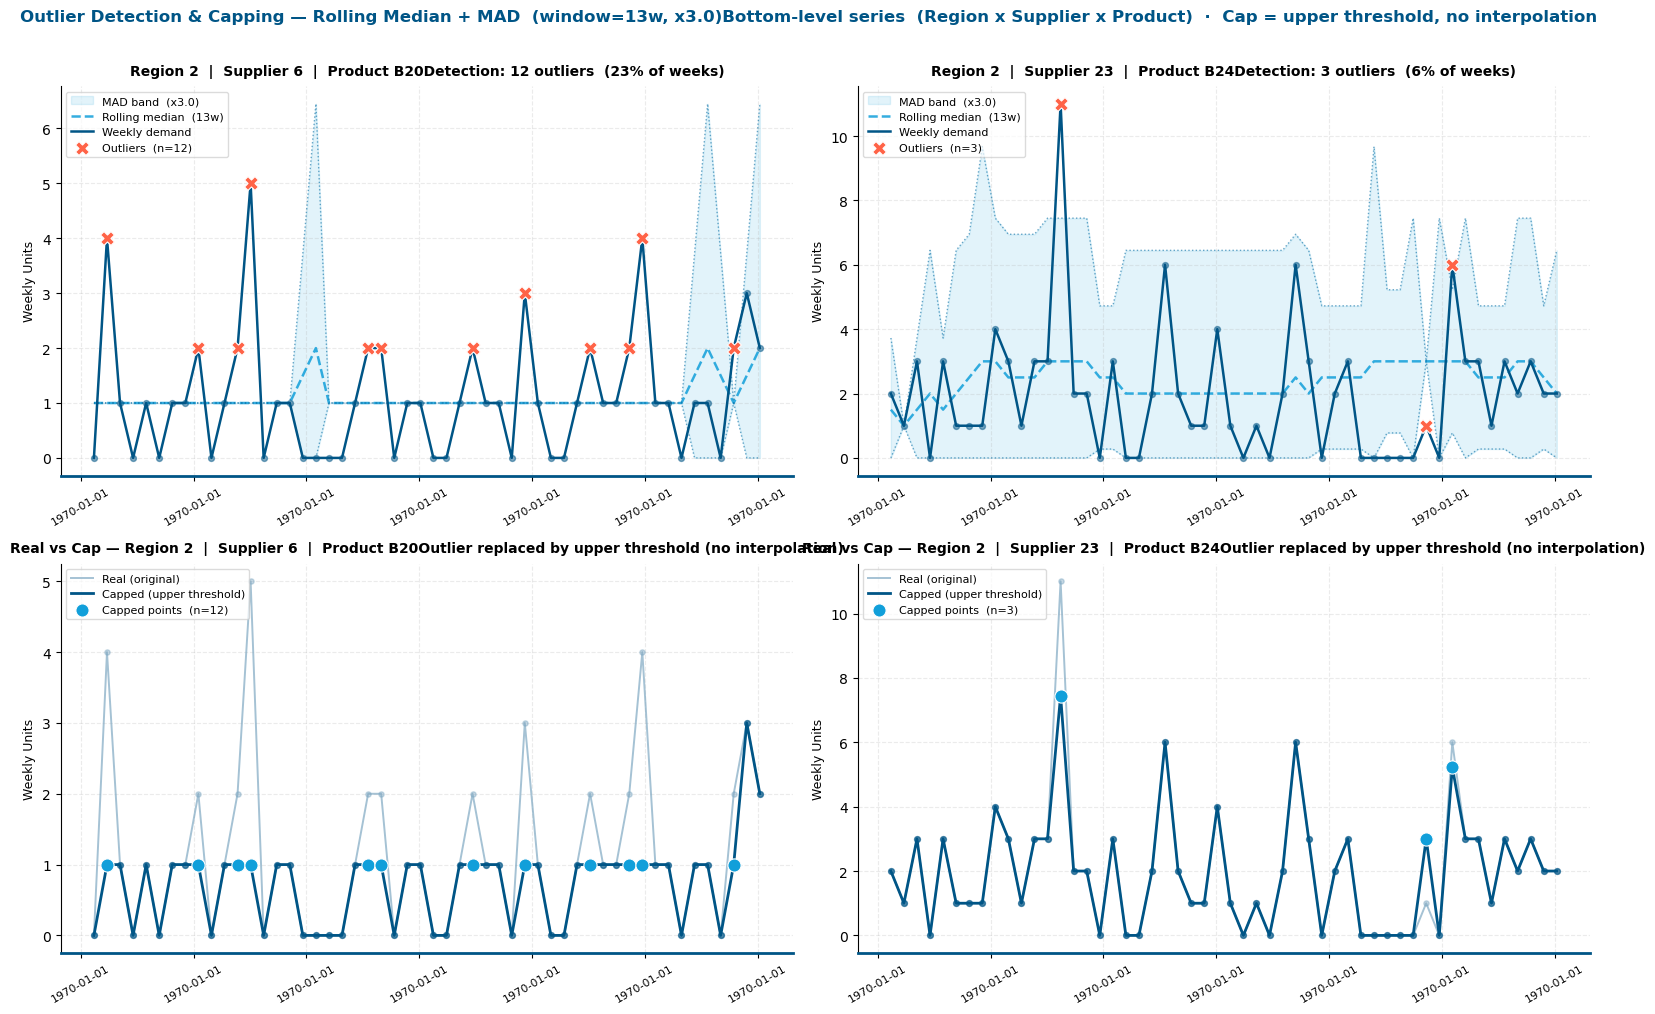

Series 1 — uid=669: 12 outliers
Series 2 — uid=2621: 3 outliers
Total: 8,260 outliers across 2,841 series with outliers


In [59]:
def _rolling_mad_detection(y, window=13, cutoff=3.0):
    """Exact logic from data_preparation.ipynb — detect_outliers_rolling_median."""
    n = len(y)
    baseline = np.full(n, np.nan)
    upper    = np.full(n, np.nan)
    lower    = np.full(n, np.nan)

    for i in range(n):
        start = max(0, i - window // 2)
        end   = min(n, i + window // 2 + 1)
        w = y[start:end]
        w = w[w > 0]
        if len(w) < 3:
            continue
        med       = np.median(w)
        mad       = np.median(np.abs(w - med))
        roll_std  = 1.4826 * mad
        baseline[i] = med
        upper[i]    = med + cutoff * roll_std
        lower[i]    = max(med - cutoff * roll_std, 0.0)

    out_mask = np.zeros(n, dtype=bool)
    for i in range(n):
        if y[i] > 0 and not np.isnan(upper[i]):
            out_mask[i] = y[i] > upper[i] or y[i] < lower[i]

    return out_mask, baseline, upper, lower


def plot_eda_outliers(df, window=13, mad_cutoff=3.0,
                      uid1=None, uid2=None, save_path=None):
    """
    2x2 figure:
      Row 0 — Rolling Median + MAD detection (original series + outlier markers)
      Row 1 — Real vs Cap: outlier points replaced by upper threshold (no interpolation)

    Series are bottom-level: Region x Supplier x Product.
    Auto-selection: uid1 = most outliers, uid2 = median outlier count.
    """
    agg_df = (
        df.groupby(["unique_id", "week_date", "region_id", "supplier_id", "product_attribute_3"],
                   observed=True, as_index=False)["y"]
        .sum()
        .sort_values(["unique_id", "week_date"])
    )

    # Pre-compute outlier count per series (only series with outliers)
    counts = {}
    for uid, grp in agg_df.groupby("unique_id", observed=True):
        y = grp["y"].values.astype(float)
        out, _, _, _ = _rolling_mad_detection(y, window, mad_cutoff)
        counts[uid] = int(out.sum())

    counts_s = pd.Series(counts).sort_values(ascending=False)
    counts_s = counts_s[counts_s > 0]

    if uid1 is None:
        uid1 = counts_s.index[0]
    if uid2 is None:
        uid2 = counts_s.index[len(counts_s) // 2]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.patch.set_facecolor("white")

    for col, uid in enumerate([uid1, uid2]):
        grp   = agg_df[agg_df["unique_id"] == uid].sort_values("week_date")
        dates = grp["week_date"].values
        y     = grp["y"].values.astype(float)

        reg  = grp["region_id"].iloc[0]
        sup  = grp["supplier_id"].iloc[0]
        prod = grp["product_attribute_3"].iloc[0]

        out_mask, base, up, lo = _rolling_mad_detection(y, window, mad_cutoff)
        n_out = out_mask.sum()

        # Cap series: replace outlier values with upper threshold
        y_cap = y.copy()
        for i in range(len(y)):
            if out_mask[i] and not np.isnan(up[i]):
                y_cap[i] = up[i]

        # ── Row 0: Detection ──────────────────────────────────────────────────
        ax = axes[0, col]
        valid = ~np.isnan(up)
        ax.fill_between(dates,
                        np.where(valid, lo,  np.nan),
                        np.where(valid, up,  np.nan),
                        color="#119FDA", alpha=0.12,
                        label=f"MAD band  (x{mad_cutoff})")
        ax.plot(dates, base, color="#119FDA", lw=1.8, alpha=0.85,
                linestyle="--", label="Rolling median  (13w)")
        ax.plot(dates, up,   color="#0A6EA3", lw=1.0, alpha=0.6, linestyle=":")
        ax.plot(dates, lo,   color="#0A6EA3", lw=1.0, alpha=0.6, linestyle=":")
        ax.plot(dates, y, color="#005586", lw=1.8, zorder=4, label="Weekly demand")
        ax.scatter(dates, y, color="#005586", s=18, zorder=5, alpha=0.5)
        if n_out:
            ax.scatter(dates[out_mask], y[out_mask],
                       color="tomato", s=100, marker="X", zorder=6,
                       edgecolors="white", linewidths=0.8,
                       label=f"Outliers  (n={n_out})")
        ax.set_title(
            f"Region {reg}  |  Supplier {sup}  |  Product {prod}"
            f"Detection: {n_out} outlier{'s' if n_out != 1 else ''}  ({n_out/len(y):.0%} of weeks)",
            fontsize=10, fontweight="bold", pad=8,
        )
        ax.set_ylabel("Weekly Units", fontsize=9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.tick_params(axis="x", rotation=30, labelsize=8)
        ax.xaxis.set_major_locator(plt.MaxNLocator(7))
        ax.legend(fontsize=8, framealpha=0.7, loc="upper left")
        ax.spines["bottom"].set_color("#005586")
        ax.spines["bottom"].set_linewidth(2)

        # ── Row 1: Real vs Cap ────────────────────────────────────────────────
        ax2 = axes[1, col]
        ax2.plot(dates, y, color="#7FA8C2", lw=1.4, alpha=0.7,
                 zorder=3, label="Real (original)")
        ax2.scatter(dates, y, color="#7FA8C2", s=14, alpha=0.45, zorder=3)
        ax2.plot(dates, y_cap, color="#005586", lw=2.0, zorder=4,
                 label="Capped (upper threshold)")
        ax2.scatter(dates, y_cap, color="#005586", s=18, zorder=5, alpha=0.6)
        # Highlight where the cap was applied
        if n_out:
            ax2.scatter(dates[out_mask], y_cap[out_mask],
                        color="#119FDA", s=90, marker="o", zorder=6,
                        edgecolors="white", linewidths=0.8,
                        label=f"Capped points  (n={n_out})")
        ax2.set_title(
            f"Real vs Cap — Region {reg}  |  Supplier {sup}  |  Product {prod}"
            f"Outlier replaced by upper threshold (no interpolation)",
            fontsize=10, fontweight="bold", pad=8,
        )
        ax2.set_ylabel("Weekly Units", fontsize=9)
        ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax2.tick_params(axis="x", rotation=30, labelsize=8)
        ax2.xaxis.set_major_locator(plt.MaxNLocator(7))
        ax2.legend(fontsize=8, framealpha=0.7, loc="upper left")
        ax2.spines["bottom"].set_color("#005586")
        ax2.spines["bottom"].set_linewidth(2)

    fig.suptitle(
        f"Outlier Detection & Capping — Rolling Median + MAD  (window={window}w, x{mad_cutoff})"
        "Bottom-level series  (Region x Supplier x Product)  ·  "
        "Cap = upper threshold, no interpolation",
        fontsize=12, fontweight="bold", y=1.01, color="#005586",
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
        print(f"Saved: {save_path}")
    plt.show()

    print(f"Series 1 — uid={uid1}: {counts[uid1]} outliers")
    print(f"Series 2 — uid={uid2}: {counts[uid2]} outliers")
    print(f"Total: {sum(counts.values()):,} outliers across {len(counts):,} series with outliers")


plot_eda_outliers(_df, save_path="../../plots/slide_eda_outliers.png")

---
## Figure — Modeling Strategy
**Slide: Modeling Strategy**

Visual summary of the 4-model routing strategy driven by demand segmentation.

Saved: ../../plots/slide_modeling_strategy.png


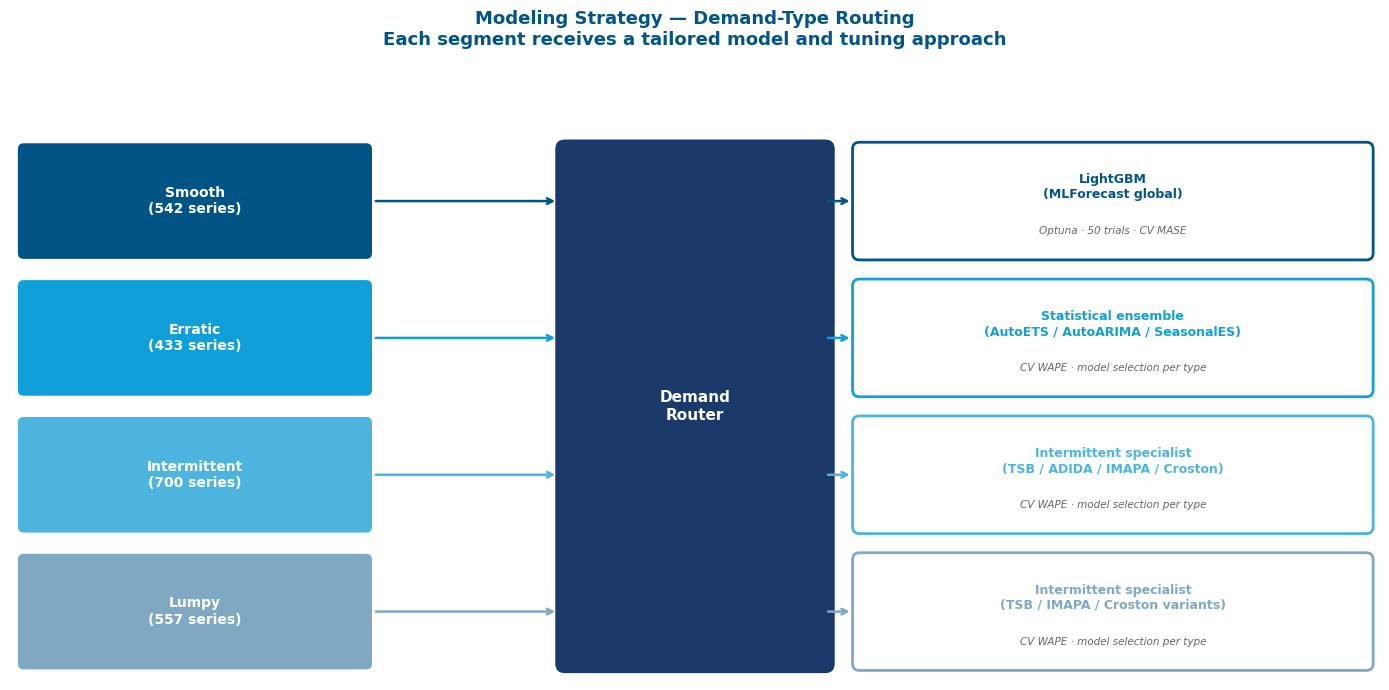

In [60]:
def plot_modeling_strategy(save_path=None):
    """
    Visual diagram of the demand-type → model routing.
    Left column: 4 demand types with series counts.
    Right column: model assigned + key tuning note.
    Connected by arrows through a central "Router" box.
    """
    import json, pathlib

    # Load series counts from tags
    counts = df_tags['demand_type'].value_counts().to_dict()

    ROWS = [
        ('smooth',       f"Smooth\n({counts.get('smooth', 0):,} series)",
         'LightGBM\n(MLForecast global)',
         'Optuna · 50 trials · CV MASE'),
        ('erratic',      f"Erratic\n({counts.get('erratic', 0):,} series)",
         'Statistical ensemble\n(AutoETS / AutoARIMA / SeasonalES)',
         'CV WAPE · model selection per type'),
        ('intermittent', f"Intermittent\n({counts.get('intermittent', 0):,} series)",
         'Intermittent specialist\n(TSB / ADIDA / IMAPA / Croston)',
         'CV WAPE · model selection per type'),
        ('lumpy',        f"Lumpy\n({counts.get('lumpy', 0):,} series)",
         'Intermittent specialist\n(TSB / IMAPA / Croston variants)',
         'CV WAPE · model selection per type'),
    ]

    MONO = {
        'smooth':       '#005586',
        'erratic':      '#119FDA',
        'intermittent': '#4DB4E0',
        'lumpy':        '#7FA8C2',
    }

    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor('white')
    ax.axis('off')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, len(ROWS) + 0.5)

    for i, (dt, demand_lbl, model_lbl, tune_lbl) in enumerate(ROWS):
        y     = len(ROWS) - i - 0.5
        color = MONO[dt]

        # ── Demand type box (left) ────────────────────────────────────────────
        box_d = FancyBboxPatch((0.1, y - 0.38), 2.5, 0.76,
                               boxstyle='round,pad=0.05',
                               facecolor=color, edgecolor='white',
                               linewidth=1.5, zorder=2)
        ax.add_patch(box_d)
        ax.text(1.35, y, demand_lbl, ha='center', va='center',
                fontsize=10, fontweight='bold', color='white', zorder=3)

        # ── Arrow left → center ───────────────────────────────────────────────
        ax.annotate('', xy=(4.0, y), xytext=(2.65, y),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.8))

        # ── Router box (center, shared) — draw only once ──────────────────────
        if i == 0:
            router_h = len(ROWS) * 0.76 + (len(ROWS) - 1) * 0.24
            router_y = (len(ROWS)) / 2 - router_h / 2
            box_r = FancyBboxPatch((4.05, router_y), 1.9, router_h,
                                   boxstyle='round,pad=0.08',
                                   facecolor='#1B3A6B', edgecolor='white',
                                   linewidth=2, zorder=2)
            ax.add_patch(box_r)
            ax.text(5.0, len(ROWS) / 2, 'Demand\nRouter',
                    ha='center', va='center',
                    fontsize=11, fontweight='bold', color='white', zorder=3)

        # ── Arrow center → right ──────────────────────────────────────────────
        ax.annotate('', xy=(6.15, y), xytext=(5.95, y),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.8))

        # ── Model box (right) ─────────────────────────────────────────────────
        box_m = FancyBboxPatch((6.2, y - 0.38), 3.7, 0.76,
                               boxstyle='round,pad=0.05',
                               facecolor='white',
                               edgecolor=color, linewidth=2, zorder=2)
        ax.add_patch(box_m)
        ax.text(8.05, y + 0.10, model_lbl,
                ha='center', va='center',
                fontsize=9, fontweight='bold', color=color, zorder=3)
        ax.text(8.05, y - 0.22, tune_lbl,
                ha='center', va='center',
                fontsize=7.5, color='#666666', zorder=3, style='italic')

    ax.set_title(
        'Modeling Strategy — Demand-Type Routing\n'
        'Each segment receives a tailored model and tuning approach',
        fontsize=13, fontweight='bold', pad=14, color='#005586',
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


plot_modeling_strategy(save_path='../../plots/slide_modeling_strategy.png')

---
## Figure — Results
**Slide: Results**

WAPE improvement vs baseline per demand type + selected model.

Saved: ../../plots/slide_results.png


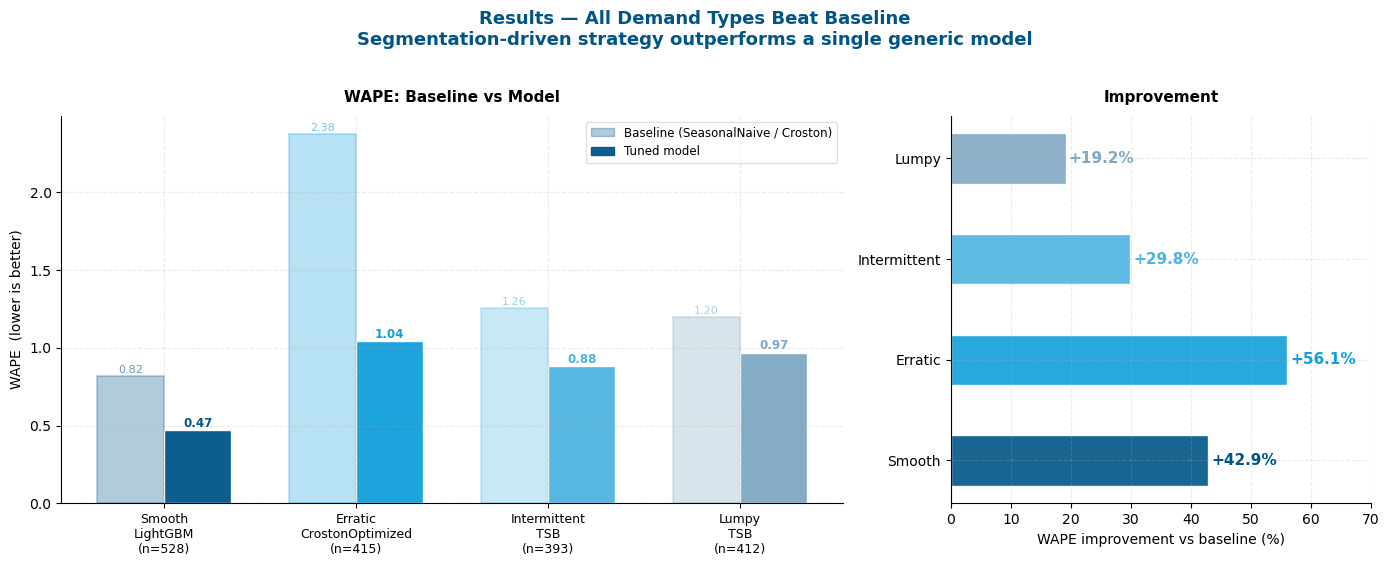

In [61]:
def plot_results(artifact_base='../../artifacts/models', save_path=None):
    """
    Two-panel results slide.
    Left : grouped bar chart — baseline WAPE vs model WAPE per demand type.
    Right: delta WAPE improvement (%) as horizontal bars.
    Loads metrics directly from metadata.json artifacts.
    """
    import json, pathlib

    DEMAND_ORDER = ['smooth', 'erratic', 'intermittent', 'lumpy']
    MONO = {
        'smooth':       '#005586',
        'erratic':      '#119FDA',
        'intermittent': '#4DB4E0',
        'lumpy':        '#7FA8C2',
    }

    # Load metadata — derive model label from model_col or class field
    records = []
    for dt in DEMAND_ORDER:
        p = pathlib.Path(artifact_base) / dt / 'metadata.json'
        if not p.exists():
            continue
        with open(p) as f:
            m = json.load(f)
        raw_label = m.get('model_col') or m.get('class', 'Unknown')
        model_label = raw_label.replace('LGBMForecaster', 'LightGBM')
        records.append({
            'demand_type':    dt,
            'baseline_wape':  m['baseline_metrics']['wape'],
            'model_wape':     m['model_metrics']['wape'],
            'delta_wape_pct': m['delta_wape_pct'],
            'model_label':    model_label,
            'n_series':       m['baseline_metrics']['n_series'],
        })

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                             gridspec_kw={'width_ratios': [1.3, 0.7]})
    fig.patch.set_facecolor('white')

    # ── Panel A: Grouped bars — baseline vs model WAPE ────────────────────────
    ax = axes[0]
    x     = np.arange(len(records))
    width = 0.35

    for j, rec in enumerate(records):
        color = MONO[rec['demand_type']]
        ax.bar(x[j] - width / 2, rec['baseline_wape'],
               width, color=color, alpha=0.30, edgecolor=color, linewidth=1.2,
               label='Baseline' if j == 0 else '')
        ax.bar(x[j] + width / 2, rec['model_wape'],
               width, color=color, alpha=0.95, edgecolor='white', linewidth=1,
               label='Model' if j == 0 else '')
        ax.text(x[j] - width / 2, rec['baseline_wape'] + 0.02,
                f"{rec['baseline_wape']:.2f}", ha='center', fontsize=8, color=color, alpha=0.6)
        ax.text(x[j] + width / 2, rec['model_wape'] + 0.02,
                f"{rec['model_wape']:.2f}", ha='center', fontsize=8.5,
                fontweight='bold', color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['demand_type'].capitalize()}\n{r['model_label']}\n(n={r['n_series']:,})"
         for r in records],
        fontsize=9,
    )
    ax.set_ylabel('WAPE  (lower is better)', fontsize=10)
    ax.set_title('WAPE: Baseline vs Model', fontsize=11, fontweight='bold', pad=10)
    ax.legend(
        handles=[
            mpatches.Patch(color='#005586', alpha=0.30, label='Baseline (SeasonalNaive / Croston)'),
            mpatches.Patch(color='#005586', alpha=0.95, label='Tuned model'),
        ],
        fontsize=8.5, framealpha=0.6, loc='upper right',
    )

    # ── Panel B: Delta WAPE improvement (horizontal bars) ─────────────────────
    ax2 = axes[1]
    y_pos = np.arange(len(records))

    for j, rec in enumerate(records):
        color = MONO[rec['demand_type']]
        ax2.barh(y_pos[j], rec['delta_wape_pct'],
                 height=0.5, color=color, alpha=0.90, edgecolor='white')
        ax2.text(rec['delta_wape_pct'] + 0.5, y_pos[j],
                 f"+{rec['delta_wape_pct']:.1f}%",
                 va='center', fontsize=11, fontweight='bold', color=color)

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(
        [r['demand_type'].capitalize() for r in records],
        fontsize=10,
    )
    ax2.set_xlabel('WAPE improvement vs baseline (%)', fontsize=10)
    ax2.set_title('Improvement', fontsize=11, fontweight='bold', pad=10)
    ax2.set_xlim(0, max(r['delta_wape_pct'] for r in records) * 1.25)
    ax2.axvline(0, color='#aaaaaa', linewidth=0.8)

    fig.suptitle(
        'Results — All Demand Types Beat Baseline\n'
        'Segmentation-driven strategy outperforms a single generic model',
        fontsize=13, fontweight='bold', y=1.02, color='#005586',
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


plot_results(save_path='../../plots/slide_results.png')

---
## Figure — Feature Engineering
**Slide: Feature Engineering**

Two-panel figure:
- **Left**: feature group diagram — categories, number of features, and key examples
- **Right**: SHAP importance bar chart for the smooth demand model (loaded from disk)

Saved: ../../plots/slide_feature_engineering.png


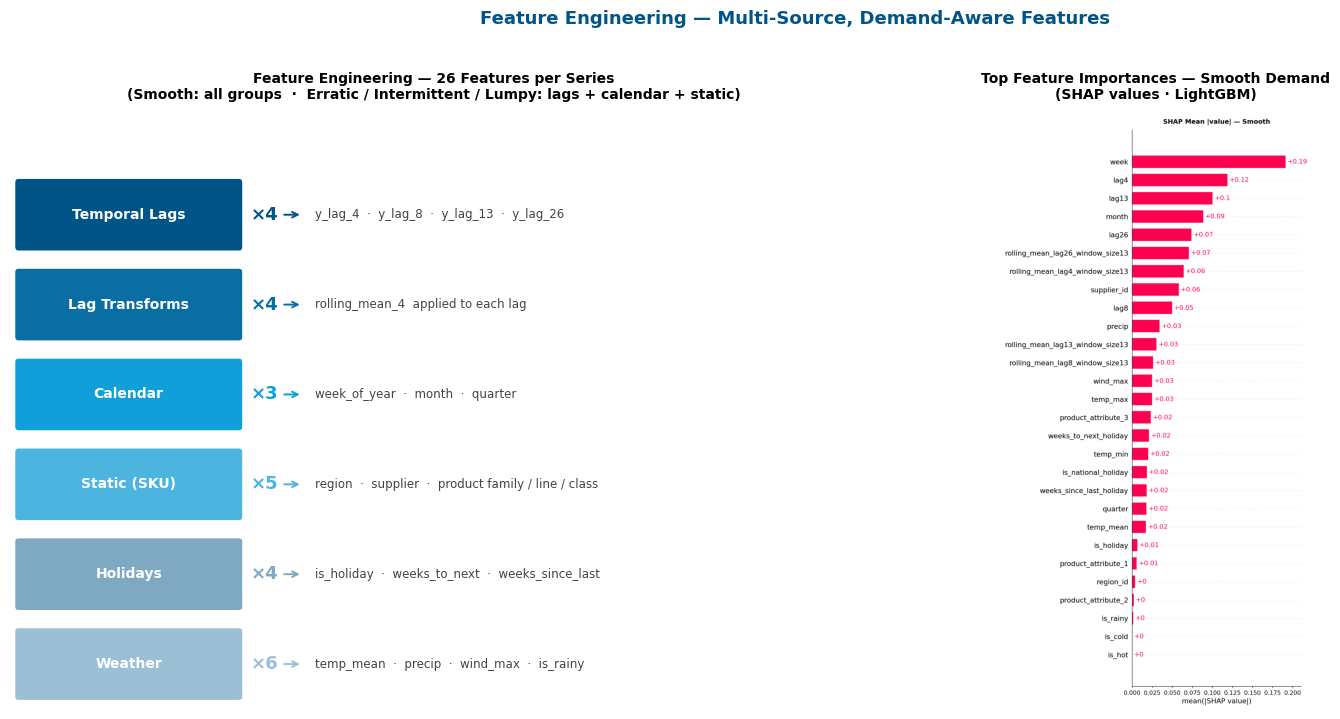

In [62]:
def plot_feature_engineering(shap_path='../../plots/shap_bar_smooth.png', save_path=None):
    """
    Two-panel feature engineering slide.
    Left : feature group diagram (category → count → key examples).
    Right: SHAP importance bar chart for smooth demand, loaded from disk.
    """
    import matplotlib.image as mpimg

    # Feature groups: (label, color, n_features, examples)
    GROUPS = [
        ('Temporal Lags',   '#005586', 4,
         'y_lag_4  ·  y_lag_8  ·  y_lag_13  ·  y_lag_26'),
        ('Lag Transforms',  '#0A6EA3', 4,
         'rolling_mean_4  applied to each lag'),
        ('Calendar',        '#119FDA', 3,
         'week_of_year  ·  month  ·  quarter'),
        ('Static (SKU)',    '#4DB4E0', 5,
         'region  ·  supplier  ·  product family / line / class'),
        ('Holidays',        '#7FA8C2', 4,
         'is_holiday  ·  weeks_to_next  ·  weeks_since_last'),
        ('Weather',         '#9BBFD4', 6,
         'temp_mean  ·  precip  ·  wind_max  ·  is_rainy'),
    ]
    total_features = sum(g[2] for g in GROUPS)

    fig = plt.figure(figsize=(16, 7))
    fig.patch.set_facecolor('white')
    ax_left  = fig.add_subplot(1, 2, 1)
    ax_right = fig.add_subplot(1, 2, 2)

    # ── Panel A: Feature groups ───────────────────────────────────────────────
    ax_left.axis('off')
    n = len(GROUPS)
    ax_left.set_xlim(0, 10)
    ax_left.set_ylim(0, n + 0.6)

    for i, (name, color, n_feats, examples) in enumerate(GROUPS):
        y = n - i - 0.5

        # Category box
        box = FancyBboxPatch((0.1, y - 0.36), 2.6, 0.72,
                             boxstyle='round,pad=0.05',
                             facecolor=color, edgecolor='white',
                             linewidth=1.5, zorder=2)
        ax_left.add_patch(box)
        ax_left.text(1.4, y, name, ha='center', va='center',
                     fontsize=10, fontweight='bold', color='white', zorder=3)

        # Count badge
        ax_left.text(3.0, y, f'×{n_feats}',
                     ha='center', va='center',
                     fontsize=13, fontweight='bold', color=color)

        # Arrow
        ax_left.annotate('', xy=(3.45, y), xytext=(3.2, y),
                         arrowprops=dict(arrowstyle='->', color=color, lw=1.4))

        # Examples
        ax_left.text(3.6, y, examples, ha='left', va='center',
                     fontsize=8.5, color='#444444')

    ax_left.set_title(
        f'Feature Engineering — {total_features} Features per Series\n'
        '(Smooth: all groups  ·  Erratic / Intermittent / Lumpy: lags + calendar + static)',
        fontsize=10, fontweight='bold', pad=12,
    )

    # ── Panel B: SHAP importance (smooth) ─────────────────────────────────────
    if os.path.exists(shap_path):
        img = mpimg.imread(shap_path)
        ax_right.imshow(img)
        ax_right.axis('off')
        ax_right.set_title(
            'Top Feature Importances — Smooth Demand\n(SHAP values · LightGBM)',
            fontsize=10, fontweight='bold', pad=12,
        )
    else:
        ax_right.text(0.5, 0.5,
                      f'SHAP plot not found:\n{shap_path}\n\nRun model_building.ipynb first.',
                      ha='center', va='center', transform=ax_right.transAxes,
                      fontsize=11, color='#888888')
        ax_right.axis('off')

    fig.suptitle(
        'Feature Engineering — Multi-Source, Demand-Aware Features',
        fontsize=13, fontweight='bold', y=1.02, color='#005586',
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


plot_feature_engineering(save_path='../../plots/slide_feature_engineering.png')